In [ ]:
from pathlib import Path
import warnings
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy
from scipy import optimize

try:
    import cvxpy as cp
except Exception:
    cp = None

from cycler import cycler

from IPython.display import display

from quantfinlab.portfolio import (
    prices_to_returns,
    make_rebalance_dates,
    estimate_covariance,
    make_psd,
    equal_weight,
    momentum_mu,
    minimum_variance,
    mean_variance,
    max_sharpe_frontier_grid)
from quantfinlab.risk import (
    corr_matrix,
    rolling_volatility,
    drawdown_summary_table,
    stress_table,
    var_es_table,
    var_backtest_table,
    best_var_methods,
    rolling_var,
)
from quantfinlab.plotting import (
    plot_corr_heatmap,
    plot_strategy_nav,
    plot_strategy_drawdowns,
    plot_stress_bar,
)
from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.reports.risk_report import risk_report

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

colors = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7",
           "#9614fa", "#DC143C", "#0072B2", "#7BC8F6", "#04D8B2", "#800080", "#FF8072"]
if cycler is not None:
    plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
plt.rcParams.update({
    "figure.figsize": (7, 3.5),
    "figure.dpi": 140,
    "savefig.dpi": 250,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8})

start_date = "2010-01-01"
end_date = None
annualization = 252
rebal_freq = "ME"
cov_lookback = 504
mu_lookback = 252
conf_lookback_months = 36
view_horizon_days = 21
ewma_lambda = 0.94
tau = 0.05
cost_bps = 10.0
w_min = 0.0
w_max = 0.25
bl_mv_lambda = 6.0
delta_fallback = 2.5
delta_min = 0.50
delta_max = 8.00
view_q_max = 0.06
view_entry_z = 0.40
max_active_views = 8
max_active_scaled_views = 5
view_tilt_max = 0.03
view_tilt_max_systematic = 0.015
active_weight_limit = 0.12
active_weight_relaxed = 0.15
gamma_te = 3.0
conf_floor = 0.10
conf_cap = 0.90
haircut_conf_floor = 0.05
haircut_conf_cap = 0.85
force_download = False
risk_free_daily = 0.0
data_dir = Path("data/raw/yfinance")
data_dir.mkdir(parents=True, exist_ok=True)

sleeve_map = {
    "SPY": "US equity", "QQQ": "US equity", "IWM": "US equity",
    "EFA": "International equity", "IEFA": "International equity", "EEM": "International equity",
    "TLT": "Duration bonds", "IEF": "Duration bonds", "SHY": "Short bonds",
    "AGG": "Core bonds", "BND": "Core bonds", "LQD": "Credit", "HYG": "Credit",
    "GLD": "Real assets", "GDX": "Real assets", "VNQ": "Real assets", "IYR": "Real assets",
    "DBC": "Commodities", "UUP": "Dollar"}


In [2]:
raw = pd.read_csv(Path(r"../data/qflab_yfinance_panel.csv"))
raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
raw = raw.dropna(subset=["date"]).sort_values("date")
raw = raw.drop_duplicates(subset=["date"], keep="last")
raw = raw.set_index("date")

close_cols = [col for col in raw.columns if str(col).endswith("__close")]
volume_cols = [col for col in raw.columns if str(col).endswith("__volume")]
dividend_cols = [col for col in raw.columns if str(col).endswith("__dividends")]
split_cols = [col for col in raw.columns if str(col).endswith("__stock_splits")]

close_all = raw[close_cols].copy()
close_all.columns = [col.rsplit("__", 1)[0] for col in close_cols]
close_all = close_all.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
close_all = close_all.dropna(axis=1, how="all").reindex(columns=sorted(close_all.columns))

volume_all = raw[volume_cols].copy()
volume_all.columns = [col.rsplit("__", 1)[0] for col in volume_cols]
volume_all = volume_all.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
volume_all = volume_all.dropna(axis=1, how="all").reindex(columns=sorted(volume_all.columns))

dividends_all = raw[dividend_cols].copy()
dividends_all.columns = [col.rsplit("__", 1)[0] for col in dividend_cols]
dividends_all = dividends_all.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
dividends_all = dividends_all.reindex(columns=sorted(dividends_all.columns))

splits_all = raw[split_cols].copy()
splits_all.columns = [col.rsplit("__", 1)[0] for col in split_cols]
splits_all = splits_all.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
splits_all = splits_all.reindex(columns=sorted(splits_all.columns))

action_parts = []
if not dividends_all.empty:
    dividends_part = dividends_all.copy()
    dividends_part.columns = pd.MultiIndex.from_product([dividends_part.columns, ["dividends"]])
    action_parts.append(dividends_part)
if not splits_all.empty:
    splits_part = splits_all.copy()
    splits_part.columns = pd.MultiIndex.from_product([splits_part.columns, ["stock_splits"]])
    action_parts.append(splits_part)
actions_all = pd.concat(action_parts, axis=1).sort_index(axis=1) if action_parts else pd.DataFrame(index=raw.index)


print("close panel:", close_all.shape, close_all.index.min().date(), "to", close_all.index.max().date())
print("volume panel:", volume_all.shape)


close panel: (4107, 56) 2010-01-04 to 2026-05-01
volume panel: (4107, 56)


In [3]:
def missing_after_first_valid(series):
    first = series.first_valid_index()
    if first is None:
        return np.nan
    return float(series.loc[first:].isna().mean())

close_after_start = close_all.loc[pd.Timestamp(start_date):].copy()
valid_tickers = []
filter_rows = []
min_project_obs = annualization * 7
for ticker in sleeve_map.keys():
    if ticker not in close_after_start.columns:
        continue
    px = close_after_start[ticker]
    valid = px.dropna()
    miss_pct = missing_after_first_valid(px)
    keep = len(valid) >= min_project_obs and (pd.notna(miss_pct) and miss_pct <= 0.05)
    filter_rows.append({"ticker": ticker, "observations": len(valid), "missing_pct_after_first_valid": miss_pct, "kept": keep})
    if keep:
        valid_tickers.append(ticker)
display(pd.DataFrame(filter_rows).round(4))

close_raw = close_after_start[valid_tickers].dropna(how="all")
close = close_raw.ffill(limit=3).dropna(how="all")
returns = prices_to_returns(close, kind="simple")

returns = returns.replace([np.inf, -np.inf], np.nan).dropna(how="all")
remaining_return_gaps = int(returns.isna().sum().sum())
if remaining_return_gaps:
    print(f"filling {remaining_return_gaps} isolated return gaps with 0.0 after price-panel cleaning")
returns_p6 = returns.fillna(0.0)
close_p6 = close.reindex(returns.index).ffill(limit=3)
assets = [ticker for ticker in returns_p6.columns if ticker != "UUP"]
close_p6 = close_p6.reindex(columns=assets)
returns_p6 = returns_p6.reindex(columns=assets)

signal_tickers = list(dict.fromkeys(assets + (["UUP"] if "UUP" in close_after_start.columns else [])))
signal_close = close_after_start[signal_tickers].ffill(limit=3).dropna(how="all")
signal_returns = signal_close.pct_change().replace([np.inf, -np.inf], np.nan).dropna(how="all").fillna(0.0)

print("assets:", assets)
print("signal assets:", list(signal_returns.columns))
print("return panel:", returns_p6.shape, returns_p6.index.min().date(), "to", returns_p6.index.max().date())


,ticker,observations,missing_pct_after_first_valid,kept
0,SPY,4107,0.0,True
1,QQQ,4107,0.0,True
2,IWM,4107,0.0,True
3,EFA,4107,0.0,True
4,IEFA,3398,0.0,True
5,EEM,4107,0.0,True
6,TLT,4107,0.0,True
7,IEF,4107,0.0,True
8,SHY,4107,0.0,True
9,AGG,4107,0.0,True


filling 709 isolated return gaps with 0.0 after price-panel cleaning
assets: ['SPY', 'QQQ', 'IWM', 'EFA', 'IEFA', 'EEM', 'TLT', 'IEF', 'SHY', 'AGG', 'BND', 'LQD', 'HYG', 'GLD', 'GDX', 'VNQ', 'IYR', 'DBC']
signal assets: ['SPY', 'QQQ', 'IWM', 'EFA', 'IEFA', 'EEM', 'TLT', 'IEF', 'SHY', 'AGG', 'BND', 'LQD', 'HYG', 'GLD', 'GDX', 'VNQ', 'IYR', 'DBC', 'UUP']
return panel: (4106, 18) 2010-01-05 to 2026-05-01


In [4]:
rebalance_dates = make_rebalance_dates(returns_p6.index, freq=rebal_freq, min_history_days=max(cov_lookback, mu_lookback, 756))
print("rebalance dates:", len(rebalance_dates))
print("first:", rebalance_dates[0].date(), "last:", rebalance_dates[-1].date())


rebalance dates: 161
first: 2013-01-31 last: 2026-05-01


In [5]:
def max_drawdown_from_nav(nav):
    nav = pd.Series(nav).dropna()
    if nav.empty:
        return np.nan
    return float((nav / nav.cummax() - 1.0).min())

rows = []
for ticker in assets:
    px = close_p6[ticker].dropna()
    ret = returns_p6[ticker].dropna()
    years = max(len(ret) / annualization, 1e-9)
    nav = (1.0 + ret).cumprod()
    rows.append({
        "ticker": ticker,
        "sleeve": sleeve_map.get(ticker, "Other"),
        "first_date": px.index.min(),
        "last_date": px.index.max(),
        "observations": int(px.shape[0]),
        "ann_return": float(nav.iloc[-1] ** (1.0 / years) - 1.0) if len(nav) else np.nan,
        "ann_vol": float(ret.std() * math.sqrt(annualization)) if len(ret) else np.nan,
        "max_drawdown": max_drawdown_from_nav(nav),
    })
table = pd.DataFrame(rows).sort_values("ticker")
display(table.round({"ann_return": 4, "ann_vol": 4, "max_drawdown": 4}))


,ticker,sleeve,first_date,last_date,observations,ann_return,ann_vol,max_drawdown
9,AGG,Core bonds,2010-01-05,2026-05-01,4106,0.0252,0.0472,-0.1843
10,BND,Core bonds,2010-01-05,2026-05-01,4106,0.0253,0.0480,-0.1858
17,DBC,Commodities,2010-01-05,2026-05-01,4106,0.0228,0.1729,-0.6614
5,EEM,International equity,2010-01-05,2026-05-01,4106,0.0470,0.2141,-0.3982
3,EFA,International equity,2010-01-05,2026-05-01,4106,0.0677,0.1839,-0.3419
14,GDX,Real assets,2010-01-05,2026-05-01,4106,0.0467,0.3803,-0.8057
13,GLD,Real assets,2010-01-05,2026-05-01,4106,0.0863,0.1653,-0.4556
12,HYG,Credit,2010-01-05,2026-05-01,4106,0.0519,0.0827,-0.2203
7,IEF,Duration bonds,2010-01-05,2026-05-01,4106,0.0263,0.0660,-0.2408
4,IEFA,International equity,2012-10-24,2026-05-01,3398,0.0686,0.1511,-0.3479


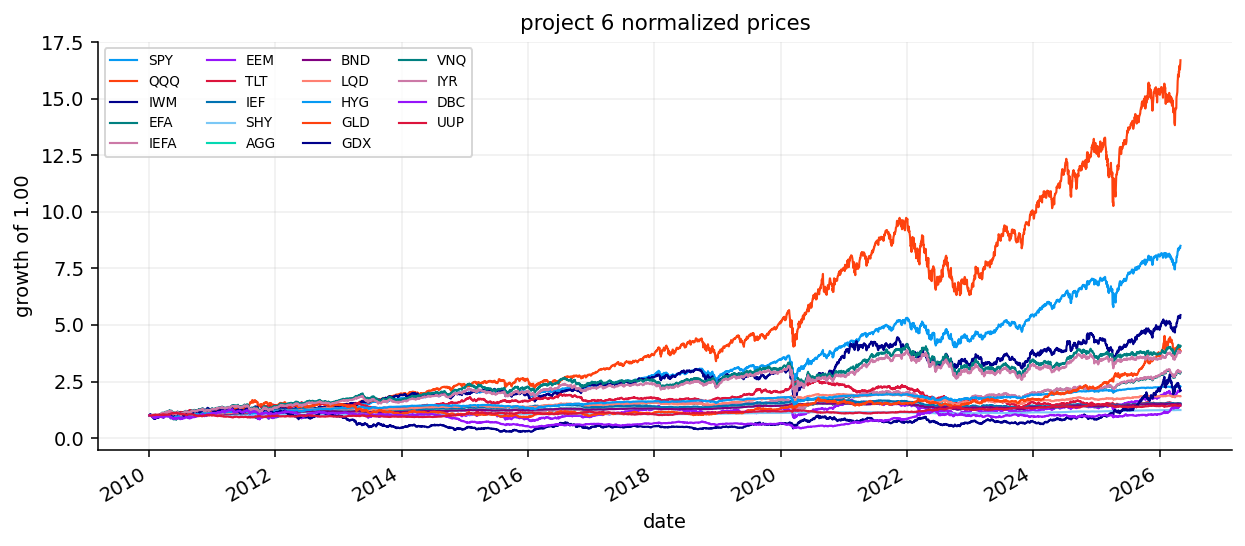

In [6]:
normalized_prices = close / close.ffill().bfill().iloc[0]
ax = normalized_prices.plot(figsize=(9, 4), lw=1.1)
ax.set_title("project 6 normalized prices")
ax.set_ylabel("growth of 1.00")
ax.set_xlabel("date")
ax.legend(ncol=4, fontsize=7)
plt.tight_layout()
plt.show()


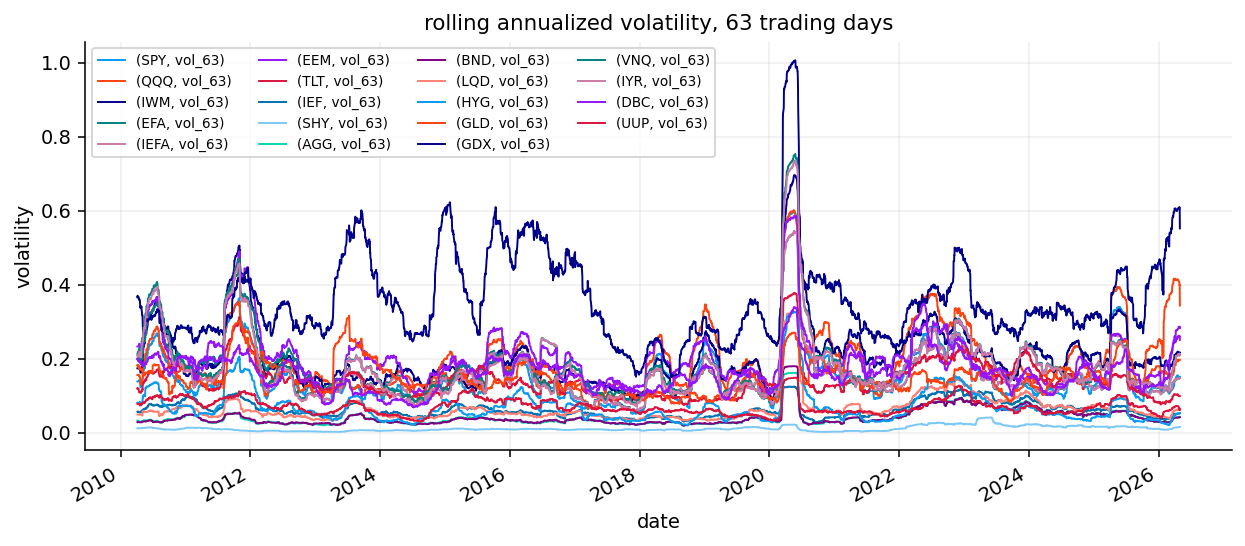

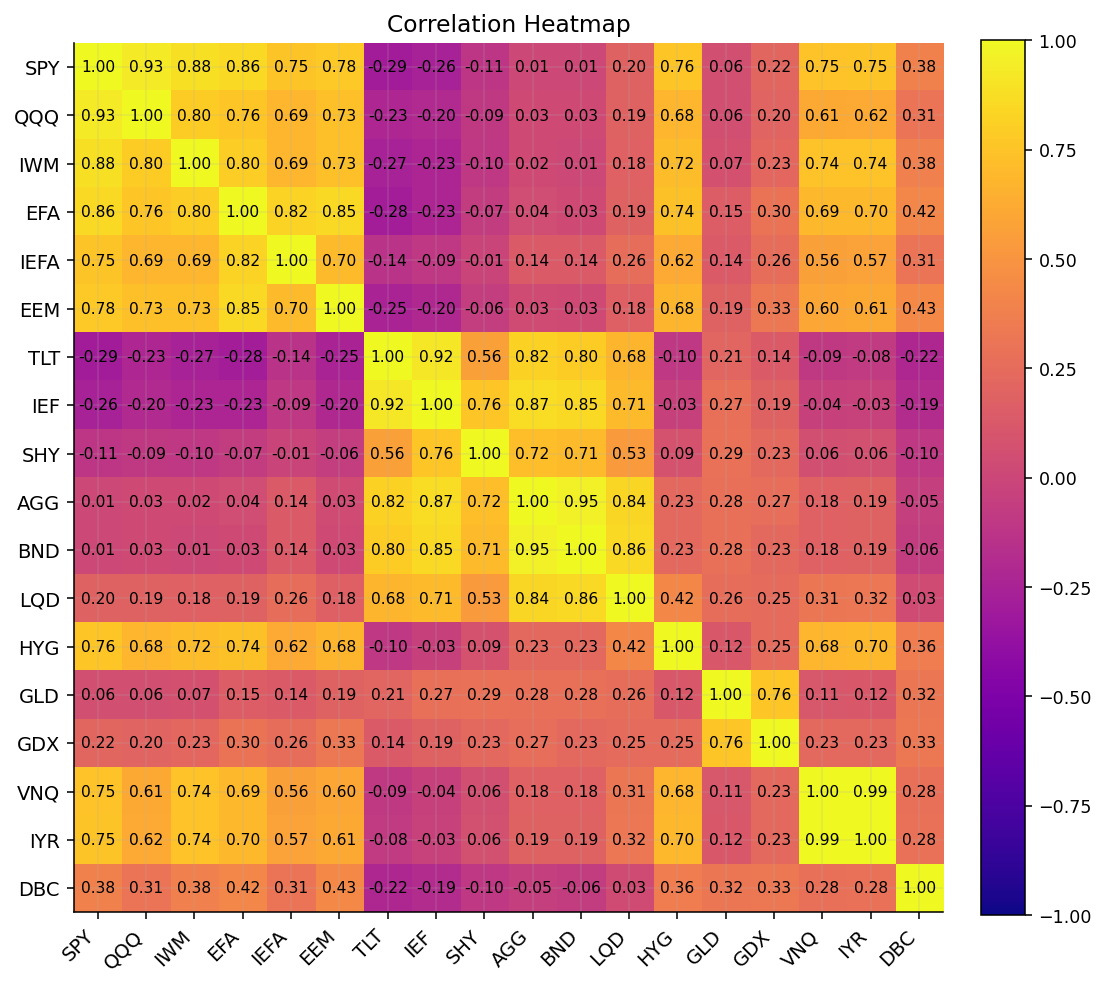

In [7]:
rolling_vol = rolling_volatility(returns, windows=(63,), annualization=annualization)
ax = rolling_vol.plot(figsize=(9, 4), lw=1.0)
ax.set_title("rolling annualized volatility, 63 trading days")
ax.set_ylabel("volatility")
ax.set_xlabel("date")
ax.legend(ncol=4, fontsize=7)
plt.tight_layout()
plt.show()

corr = corr_matrix(returns_p6)
fig, ax = plt.subplots(figsize=(8, 8))
ax = plot_corr_heatmap(ax, corr)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [8]:
fixed_benchmark_weights = {
    "SPY": 0.22, "QQQ": 0.08, "IWM": 0.04, "EFA": 0.09, "EEM": 0.05,
    "TLT": 0.08, "IEF": 0.08, "SHY": 0.05, "AGG": 0.10, "LQD": 0.05,
    "HYG": 0.04, "GLD": 0.05, "VNQ": 0.04, "DBC": 0.02, "UUP": 0.01}

asset_cap_map = {
    "SPY": 0.35, "QQQ": 0.25, "IWM": 0.15, "EFA": 0.20, "EEM": 0.15,
    "TLT": 0.25, "IEF": 0.25, "SHY": 0.20, "AGG": 0.25,
    "LQD": 0.15, "HYG": 0.08, "GLD": 0.10, "VNQ": 0.08, "DBC": 0.05}

asset_caps = pd.Series({asset: asset_cap_map.get(asset, w_max) for asset in assets}, index=assets, dtype=float)

sleeve_constraints = {
    "equity": {"assets": ["SPY", "QQQ", "IWM", "EFA", "EEM"], "min": 0.35, "max": 0.75},
    "bonds": {"assets": ["TLT", "IEF", "SHY", "AGG"], "min": 0.15, "max": 0.55},
    "credit": {"assets": ["LQD", "HYG"], "min": 0.00, "max": 0.18},
    "real_assets": {"assets": ["GLD", "VNQ", "DBC"], "min": 0.00, "max": 0.22}}

def normalize_box_weights(raw_weights, index, lower=0.0, upper=0.25):
    w = pd.Series(raw_weights, index=index, dtype=float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    upper_s = pd.Series(upper, index=index, dtype=float) if np.isscalar(upper) else pd.Series(upper, index=index, dtype=float).reindex(index).fillna(w_max)
    w = w.clip(lower=max(lower, 0.0), upper=upper_s)
    if w.sum() <= 0:
        w = pd.Series(1.0 / len(index), index=index).clip(upper=upper_s)
    else:
        w = w / w.sum()
    if upper_s.sum() < 1.0 - 1e-10:
        return pd.Series(1.0 / len(index), index=index)
    for _ in range(100):
        over = w > upper_s + 1e-12
        if not over.any():
            break
        excess = float((w[over] - upper_s[over]).sum())
        w[over] = upper_s[over]
        room = (upper_s[~over] - w[~over]).clip(lower=0.0)
        if room.sum() <= 1e-12:
            break
        w.loc[room.index] = w.loc[room.index] + excess * room / room.sum()
    w = w.clip(lower=lower, upper=upper_s)
    w = w / w.sum() if w.sum() > 0 else pd.Series(1.0 / len(index), index=index)
    return w

benchmark_raw = {ticker: fixed_benchmark_weights.get(ticker, 0.0) for ticker in assets}
benchmark_w = normalize_box_weights(benchmark_raw, assets, lower=w_min, upper=asset_caps)
if (benchmark_w > asset_caps + 1e-6).any() or abs(benchmark_w.sum() - 1.0) > 1e-6:
    benchmark_w = normalize_box_weights(pd.Series(1.0, index=assets), assets, lower=w_min, upper=asset_caps)
benchmark_table = pd.DataFrame({"asset": benchmark_w.index, "sleeve": [sleeve_map.get(ticker, "Other") for ticker in benchmark_w.index], "benchmark_weight": benchmark_w.values, "asset_cap": asset_caps.reindex(benchmark_w.index).values})
display(benchmark_table.round(4))


,asset,sleeve,benchmark_weight,asset_cap
0,SPY,US equity,0.2222,0.35
1,QQQ,US equity,0.0808,0.25
2,IWM,US equity,0.0404,0.15
3,EFA,International equity,0.0909,0.20
4,IEFA,International equity,0.0000,0.25
5,EEM,International equity,0.0505,0.15
6,TLT,Duration bonds,0.0808,0.25
7,IEF,Duration bonds,0.0808,0.25
8,SHY,Short bonds,0.0505,0.20
9,AGG,Core bonds,0.1010,0.25


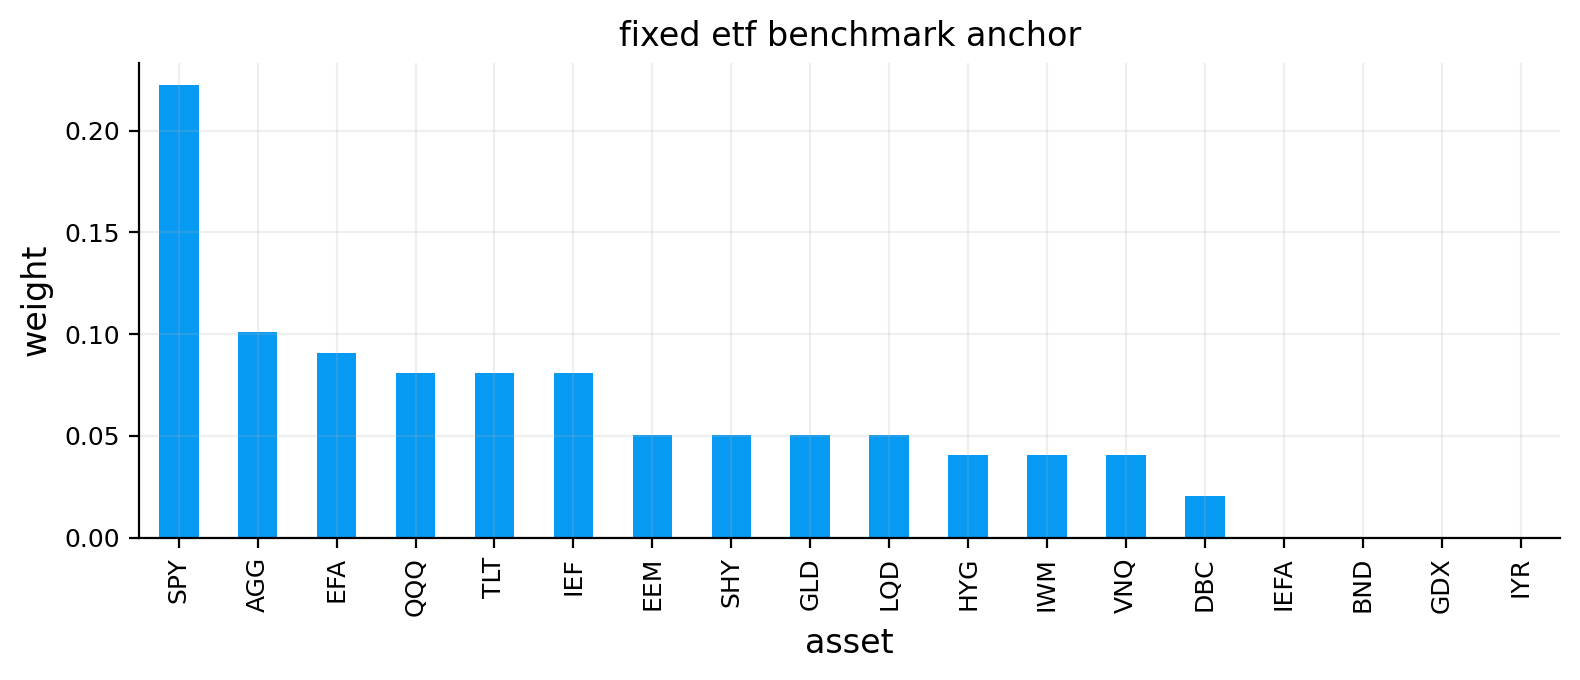

,sleeve,benchmark_weight
7,US equity,0.3434
3,Duration bonds,0.1616
4,International equity,0.1414
1,Core bonds,0.1010
5,Real assets,0.0909
2,Credit,0.0909
6,Short bonds,0.0505
0,Commodities,0.0202


In [9]:
fig, ax = plt.subplots(figsize=(8, 3.5))
benchmark_w.sort_values(ascending=False).plot(kind="bar", ax=ax)
ax.set_title("fixed etf benchmark anchor")
ax.set_ylabel("weight")
ax.set_xlabel("asset")
plt.tight_layout()
plt.show()
benchmark_sleeve = benchmark_table.groupby("sleeve", as_index=False)["benchmark_weight"].sum().sort_values("benchmark_weight", ascending=False)
display(benchmark_sleeve.round(4))


In [10]:
def local_make_psd(matrix, eps=1e-10):
    arr = np.asarray(matrix, dtype=float)
    arr = 0.5 * (arr + arr.T)
    vals, vecs = np.linalg.eigh(arr)
    vals = np.maximum(vals, eps)
    out = (vecs * vals) @ vecs.T
    return 0.5 * (out + out.T)

def make_psd_df(matrix, index):
    arr = make_psd(np.asarray(matrix, dtype=float), eps=1e-10)
    return pd.DataFrame(arr, index=index, columns=index)

def estimate_ewma_cov_at_date(returns, date, lookback=cov_lookback, lam=ewma_lambda):
    date = pd.Timestamp(date)
    pos = returns.index.searchsorted(date, side="right") - 1
    window = returns.iloc[max(0, pos - lookback + 1):pos + 1].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    cov_ann = estimate_covariance(window, method="EWMA", annualization=annualization, ewma_lambda=lam, return_df=True)
    return cov_ann


def estimate_delta_at_date(returns, date, benchmark_w, lookback=cov_lookback):
    date = pd.Timestamp(date)
    pos = returns.index.searchsorted(date, side="right") - 1
    window = returns.iloc[max(0, pos - lookback + 1):pos + 1][benchmark_w.index].fillna(0.0)
    bench_ret = window @ benchmark_w
    ann_return = float(bench_ret.mean() * annualization)
    ann_var = float(bench_ret.var(ddof=1) * annualization)
    raw_delta = delta_fallback if (not np.isfinite(ann_var) or ann_var <= 1e-10) else (ann_return - risk_free_daily * annualization) / ann_var
    if not np.isfinite(raw_delta):
        raw_delta = delta_fallback
    return float(np.clip(raw_delta, delta_min, delta_max))

cov_by_date = {}
delta_by_date = {}
prior_mu_by_date = {}
for dt in rebalance_dates:
    cov_ann = estimate_ewma_cov_at_date(returns, dt)
    delta_t = estimate_delta_at_date(returns, dt, benchmark_w)
    prior_mu = pd.Series(delta_t * cov_ann.loc[assets, assets].values @ benchmark_w.loc[assets].values, index=assets)
    cov_by_date[pd.Timestamp(dt)] = cov_ann
    delta_by_date[pd.Timestamp(dt)] = delta_t
    prior_mu_by_date[pd.Timestamp(dt)] = prior_mu
print("stored covariance and prior for", len(prior_mu_by_date), "rebalance dates")


stored covariance and prior for 161 rebalance dates


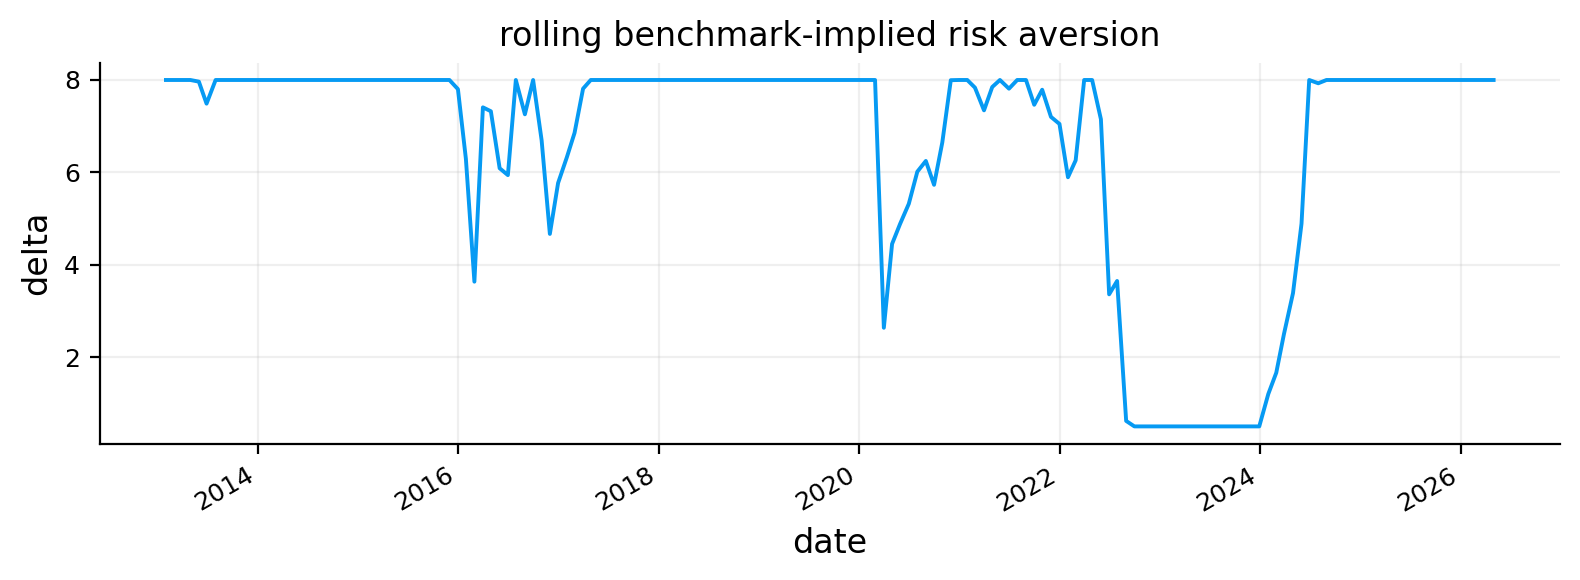

,asset,prior_mu,benchmark_weight
0,GDX,0.2980,0.0000
1,EEM,0.2058,0.0505
2,IEFA,0.1580,0.0000
3,EFA,0.1579,0.0909
4,GLD,0.1486,0.0505
5,IWM,0.1471,0.0404
6,QQQ,0.1335,0.0808
7,SPY,0.1086,0.2222
8,IYR,0.0804,0.0000
9,VNQ,0.0778,0.0404


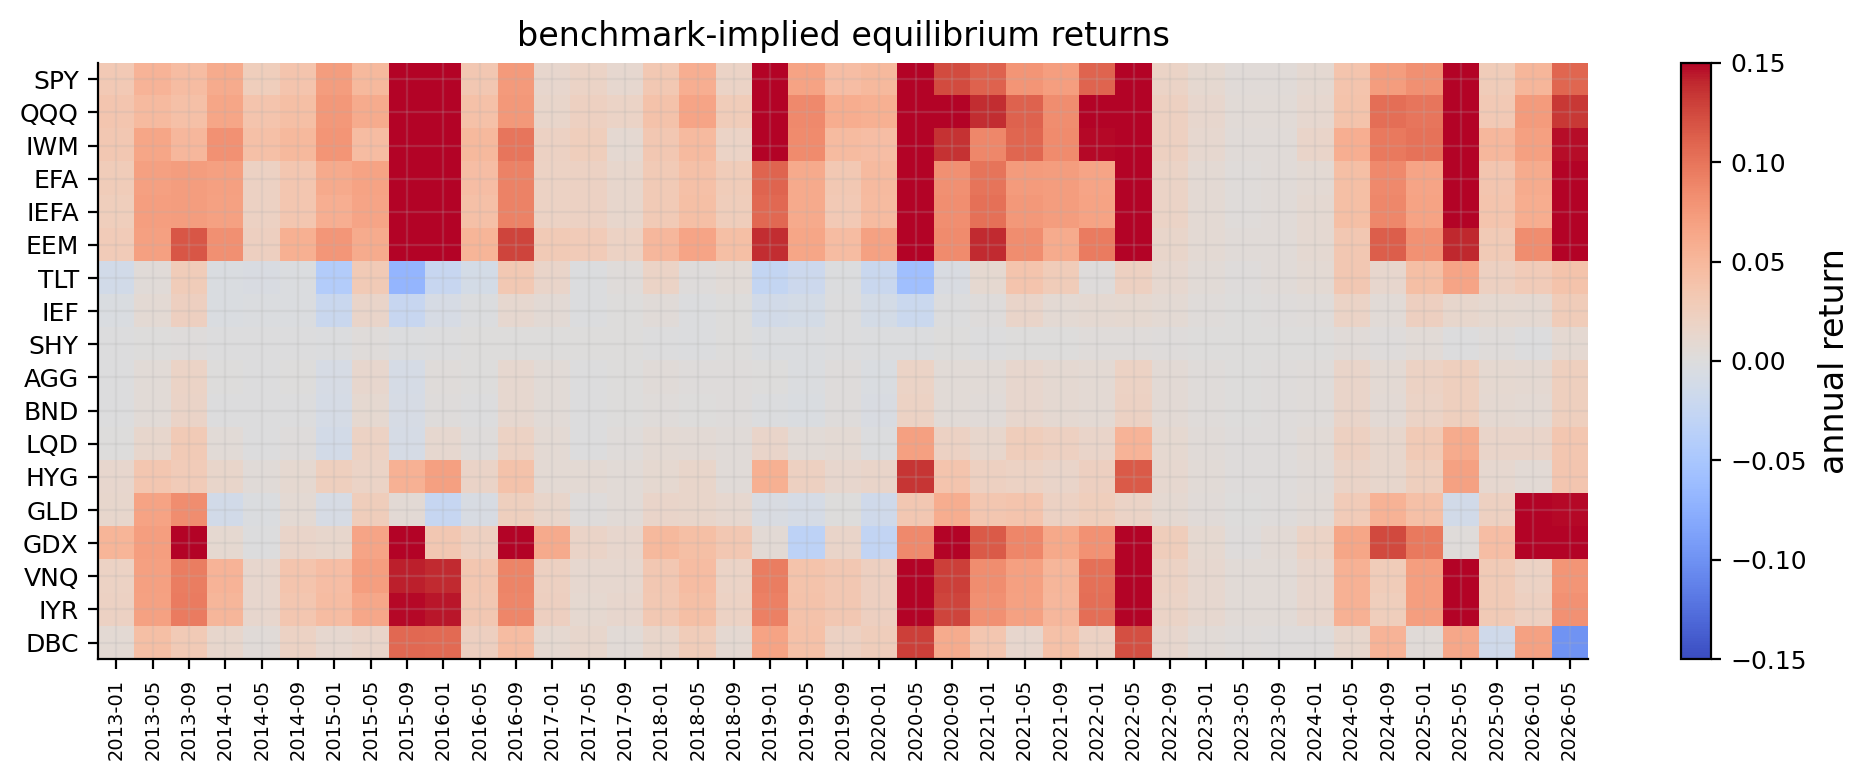

In [11]:
delta_series = pd.Series(delta_by_date).sort_index()
ax = delta_series.plot(figsize=(8, 3), lw=1.4)
ax.set_title("rolling benchmark-implied risk aversion")
ax.set_ylabel("delta")
ax.set_xlabel("date")
plt.tight_layout()
plt.show()

latest_rebalance_date = rebalance_dates[-1]
latest_prior = prior_mu_by_date[pd.Timestamp(latest_rebalance_date)].sort_values(ascending=False)
prior_table = pd.DataFrame({"asset": latest_prior.index, "prior_mu": latest_prior.values, "benchmark_weight": benchmark_w.reindex(latest_prior.index).values})
display(prior_table.round(4))

prior_mu_frame = pd.DataFrame(prior_mu_by_date).T.sort_index()
prior_mu_heat = prior_mu_frame.iloc[::max(1, len(prior_mu_frame) // 36)].T
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(prior_mu_heat, aspect="auto", cmap="coolwarm", vmin=-0.15, vmax=0.15)
ax.set_title("benchmark-implied equilibrium returns")
ax.set_yticks(range(len(prior_mu_heat.index)), prior_mu_heat.index)
ax.set_xticks(range(len(prior_mu_heat.columns)), [d.strftime("%Y-%m") for d in prior_mu_heat.columns], rotation=90, fontsize=7)
fig.colorbar(im, ax=ax, label="annual return")
plt.tight_layout()
plt.show()


In [12]:
def simple_nav(returns):
    returns = pd.Series(returns).dropna()
    return (1.0 + returns).cumprod()

def simple_drawdown(nav):
    nav = pd.Series(nav).dropna()
    return nav / nav.cummax() - 1.0

def equal_weight_vector(index):
    out = equal_weight(list(index), w_min=w_min, w_max=w_max, long_only=True, as_series=True)
    return out.reindex(index).fillna(0.0).to_numpy(dtype=float)

def clean_weight_array(weights, index, previous=None):
    if weights is None:
        weights = previous if previous is not None else equal_weight_vector(index)
    w = np.asarray(weights, dtype=float).reshape(-1)
    if len(w) != len(index) or not np.all(np.isfinite(w)):
        w = equal_weight_vector(index) if previous is None else np.asarray(previous, dtype=float)
    w = np.maximum(w, w_min)
    w = np.minimum(w, w_max)
    w = w / w.sum() if w.sum() > 1e-12 else equal_weight_vector(index)
    for _ in range(10):
        over = w > w_max
        if not over.any():
            break
        extra = (w[over] - w_max).sum()
        w[over] = w_max
        room = np.maximum(w_max - w[~over], 0.0)
        if room.sum() <= 1e-12:
            break
        w[~over] += extra * room / room.sum()
    w = np.maximum(w, w_min)
    w = np.minimum(w, w_max)
    return w / w.sum()

def momentum_mu_at_date(returns, date, mode="6-1", cov_ann=None):
    pos = returns.index.searchsorted(pd.Timestamp(date), side="right") - 1
    window = returns.iloc[max(0, pos - mu_lookback + 1):pos + 1].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    mu = momentum_mu(window, cov_ann=cov_ann, mode=mode, target_sharpe_ann=0.8, mu_cap_ann=0.30, annualization=annualization, return_series=True)
    return pd.Series(mu).replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(-0.30, 0.30).reindex(assets).fillna(0.0)

def min_variance_weights(cov_ann, w_prev=None):
    w = minimum_variance(cov_ann=cov_ann, w_prev=w_prev, w_min=w_min, w_max=w_max, long_only=True, turnover_penalty_bps=cost_bps, raise_on_fail=False)
    return clean_weight_array(w, cov_ann.index, previous=w_prev), w is None
        

def mean_variance_weights(mu, cov_ann, w_prev=None, mv_lambda=bl_mv_lambda):
    w = mean_variance(mu_excess_ann=mu, cov_ann=cov_ann, w_prev=w_prev, mv_lambda=mv_lambda, w_min=w_min, w_max=w_max, long_only=True, turnover_penalty_bps=cost_bps, raise_on_fail=False)
    return clean_weight_array(w, cov_ann.index, previous=w_prev), w is None

def max_sharpe_fg_weights(mu, cov_ann, w_prev=None):
    w = max_sharpe_frontier_grid(mu_excess_ann=mu, cov_ann=cov_ann, w_prev=w_prev, grid_n=15, w_min=w_min, w_max=w_max, long_only=True, turnover_penalty_bps=cost_bps, raise_on_fail=False)
    return clean_weight_array(w, cov_ann.index, previous=w_prev), w is None


In [13]:
def backtest_result_to_dict(name, result, fallback_flags=None):
    flags = pd.Series(dtype=float) if fallback_flags is None else pd.Series(fallback_flags).sort_index()
    return {
        "returns": result.net_returns.rename(name),
        "gross_returns": result.gross_returns.rename(name),
        "nav": result.net_values.rename(name),
        "gross_nav": result.gross_values.rename(name),
        "weights": result.weights.copy(),
        "turnover": result.turnover.rename(name),
        "costs": result.costs.rename(name),
        "fallback_flags": flags.rename(name),
        "fallback_count": int(flags.sum()) if len(flags) else int(result.fallbacks),
    }

def make_weight_schedule(weight_func):
    rows = []
    fallback_rows = []
    w_prev = None
    for dt in rebalance_dates[:-1]:
        dt = pd.Timestamp(dt)
        w_new, fallback = weight_func(dt, w_prev)
        w_new = clean_weight_array(w_new, assets, previous=w_prev)
        rows.append(pd.Series(w_new, index=assets, name=dt))
        fallback_rows.append((dt, int(bool(fallback))))
        w_prev = w_new
    return pd.DataFrame(rows), pd.Series(dict(fallback_rows), dtype=float).sort_index()

def ew_weight_func(dt, w_prev):
    return equal_weight_vector(assets), False

def make_momentum_weight_func(mode):
    def weight_func(dt, w_prev):
        cov_ann = cov_by_date[pd.Timestamp(dt)].loc[assets, assets]
        mu = momentum_mu_at_date(returns_p6, dt, mode=mode, cov_ann=cov_ann)
        return mean_variance_weights(mu, cov_ann, w_prev=w_prev, mv_lambda=bl_mv_lambda)
    return weight_func

def maxsharpe_fg_mom_weight_func(dt, w_prev):
    cov_ann = cov_by_date[pd.Timestamp(dt)].loc[assets, assets]
    mu = momentum_mu_at_date(returns_p6, dt, mode="6-1", cov_ann=cov_ann)
    return max_sharpe_fg_weights(mu, cov_ann, w_prev=w_prev)

baseline_weight_schedules = {}
baseline_fallback_flags = {}
baseline_weight_schedules["Equal Weight"], baseline_fallback_flags["Equal Weight"] = make_weight_schedule(ew_weight_func)
baseline_weight_schedules["MaxSharpe_FG_EWMA_Mom"], baseline_fallback_flags["MaxSharpe_FG_EWMA_Mom"] = make_weight_schedule(maxsharpe_fg_mom_weight_func)
for mode in ["3-0", "6-1", "12-1"]:
    name = f"EWMA Momentum-MV {mode}"
    baseline_weight_schedules[name], baseline_fallback_flags[name] = make_weight_schedule(make_momentum_weight_func(mode))

baseline_backtests = run_many_weights_backtests(
    baseline_weight_schedules,
    returns=returns_p6[assets],
    cost_bps=cost_bps,
    w_min=w_min,
    w_max=None,
    long_only=True,
    normalize=True,
    weight_timing="next_close",
)
baseline_candidates = {name: backtest_result_to_dict(name, result, baseline_fallback_flags[name]) for name, result in baseline_backtests.items()}
print("baseline candidates:", list(baseline_candidates))


baseline candidates: ['Equal Weight', 'MaxSharpe_FG_EWMA_Mom', 'EWMA Momentum-MV 3-0', 'EWMA Momentum-MV 6-1', 'EWMA Momentum-MV 12-1']


In [14]:
def quick_metrics(ret, nav=None):
    ret = pd.Series(ret).dropna()
    nav = simple_nav(ret) if nav is None else pd.Series(nav).dropna()
    if ret.empty or nav.empty:
        return {"cagr": np.nan, "ann_vol": np.nan, "sharpe": np.nan, "max_drawdown": np.nan}
    years = max(len(nav) / annualization, 1e-9)
    cagr = float(nav.iloc[-1] ** (1.0 / years) - 1.0)
    ann_vol = float(ret.std(ddof=1) * math.sqrt(annualization))
    sharpe = float((ret.mean() - risk_free_daily) / ret.std(ddof=1) * math.sqrt(annualization)) if ret.std(ddof=1) > 1e-12 else np.nan
    return {"cagr": cagr, "ann_vol": ann_vol, "sharpe": sharpe, "max_drawdown": max_drawdown_from_nav(nav)}

candidate_rows = []
for name, result in baseline_candidates.items():
    m = quick_metrics(result["returns"], result["nav"])
    candidate_rows.append({"strategy": name, "cagr": m["cagr"], "ann_vol": m["ann_vol"], "sharpe": m["sharpe"], "max_drawdown": m["max_drawdown"], "avg_turnover": result["turnover"].mean(), "fallback_count": result["fallback_count"]})
baseline_candidate_summary = pd.DataFrame(candidate_rows).sort_values("sharpe", ascending=False)
display(baseline_candidate_summary.round(4))
momentum_names = [name for name in baseline_candidates if name.startswith("EWMA Momentum-MV")]
best_momentum_name = baseline_candidate_summary[baseline_candidate_summary["strategy"].isin(momentum_names)].iloc[0]["strategy"]
baseline_results = {
    "Equal Weight": baseline_candidates["Equal Weight"],
    "MaxSharpe_FG_EWMA_Mom": baseline_candidates["MaxSharpe_FG_EWMA_Mom"],
    "EWMA Momentum MV": baseline_candidates[best_momentum_name],
}
print("ex-post finalist selection for comparing model families, not a live hyperparameter-selection rule")
print("selected momentum mv:", best_momentum_name)


,strategy,cagr,ann_vol,sharpe,max_drawdown,avg_turnover,fallback_count
4,EWMA Momentum-MV 12-1,0.0443,0.0492,0.9075,-0.1373,0.1704,0
3,EWMA Momentum-MV 6-1,0.0395,0.0480,0.8310,-0.1464,0.1769,0
1,MaxSharpe_FG_EWMA_Mom,0.0860,0.1070,0.8227,-0.1977,0.3210,0
0,Equal Weight,0.0672,0.0975,0.7139,-0.2154,0.0156,0
2,EWMA Momentum-MV 3-0,0.0301,0.0500,0.6180,-0.1348,0.2365,0


ex-post finalist selection for comparing model families, not a live hyperparameter-selection rule
selected momentum mv: EWMA Momentum-MV 12-1


,avg_turnover
Equal Weight,0.0156
MaxSharpe_FG_EWMA_Mom,0.3210
EWMA Momentum MV,0.1704


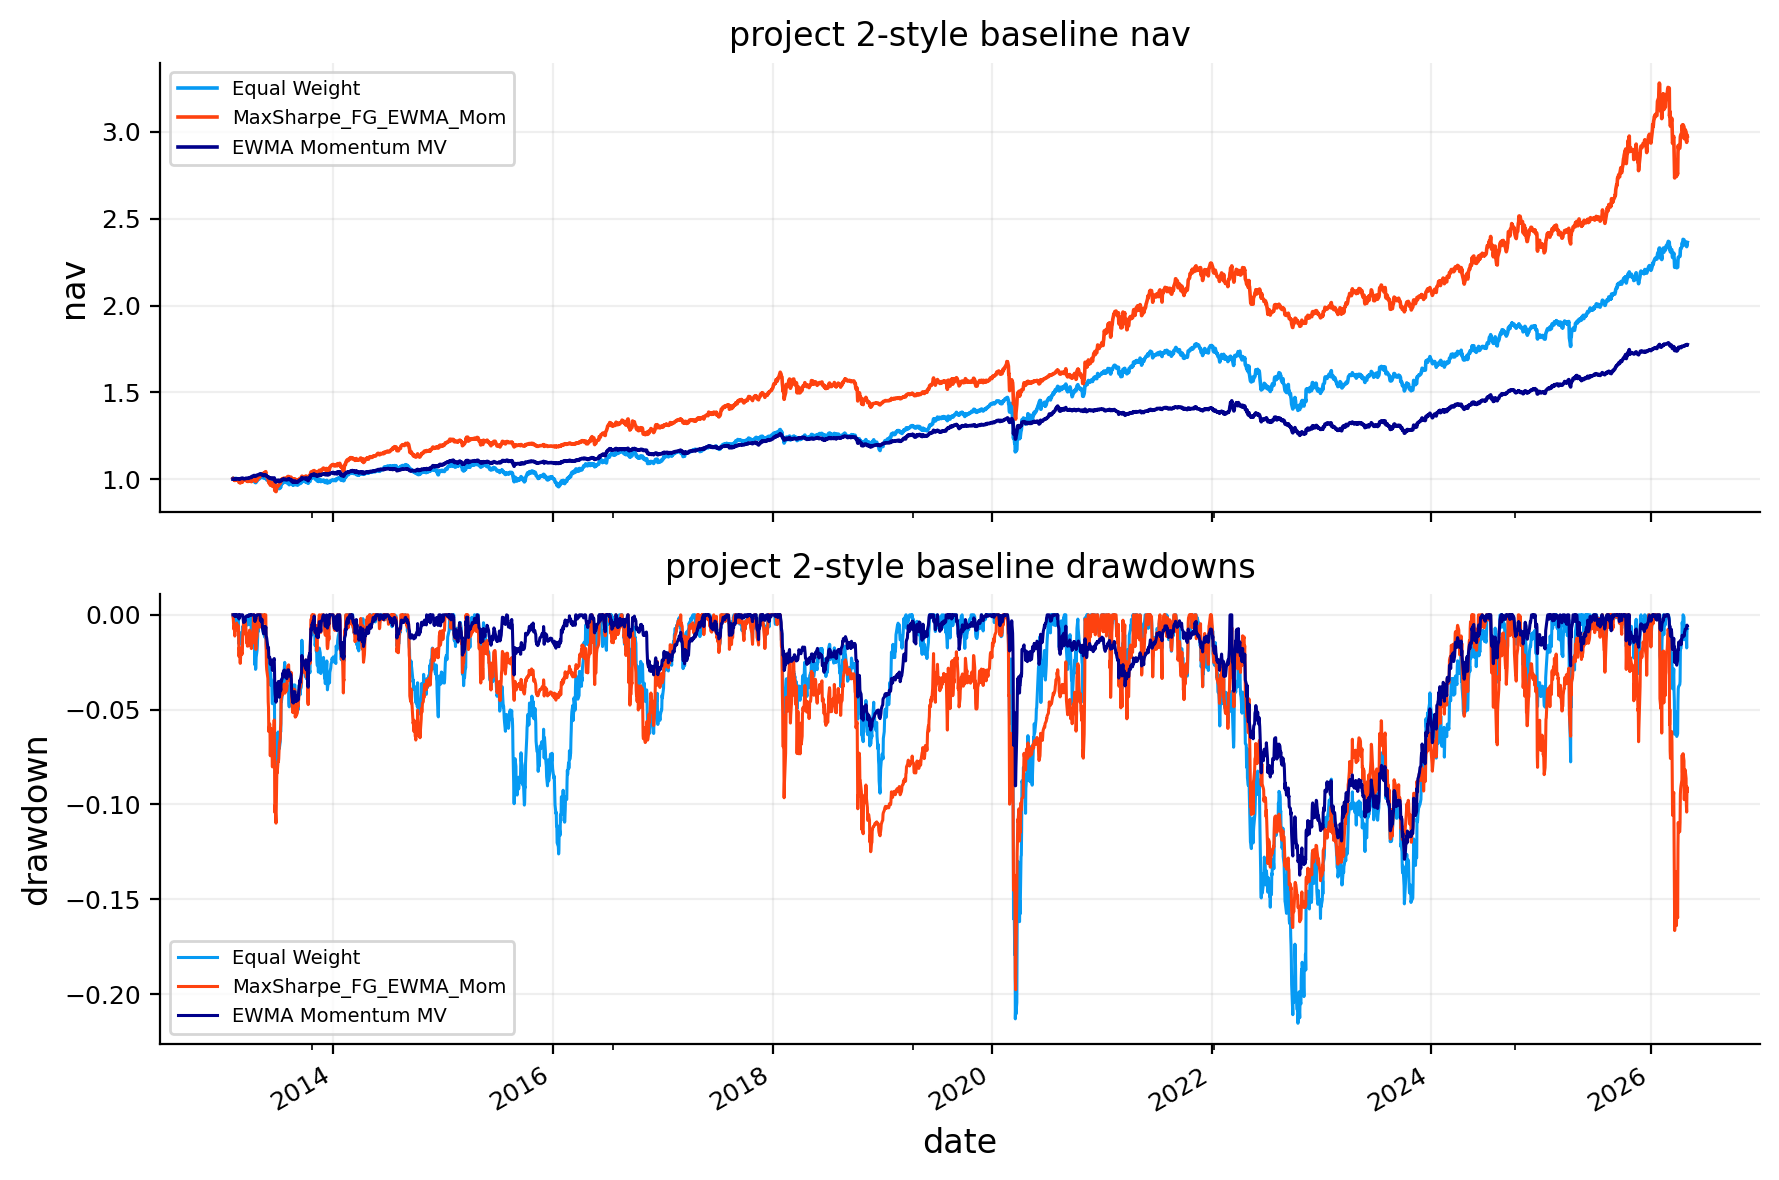

In [15]:
avg_turnover_table = pd.DataFrame({name: result["turnover"].mean() for name, result in baseline_results.items()}, index=["avg_turnover"]).T
display(avg_turnover_table.round(4))
baseline_nav = pd.DataFrame({name: result["nav"] for name, result in baseline_results.items()})
baseline_dd = baseline_nav / baseline_nav.cummax() - 1.0
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
baseline_nav.plot(ax=axes[0], lw=1.3)
axes[0].set_title("project 2-style baseline nav"); axes[0].set_ylabel("nav")
baseline_dd.plot(ax=axes[1], lw=1.1)
axes[1].set_title("project 2-style baseline drawdowns"); axes[1].set_ylabel("drawdown"); axes[1].set_xlabel("date")
plt.tight_layout(); plt.show()


In [16]:
risky_asset_names = ["SPY", "QQQ", "IWM", "EFA", "EEM", "HYG", "VNQ", "DBC"]
defensive_asset_names = ["TLT", "IEF", "SHY", "AGG", "LQD", "GLD"]

def winsorized_zscore(series):
    s = pd.Series(series, dtype=float).replace([np.inf, -np.inf], np.nan)
    good = s.dropna()
    if good.empty:
        return pd.Series(0.0, index=s.index)
    clipped = s.clip(good.quantile(0.05), good.quantile(0.95))
    std = clipped.std(ddof=0)
    if not np.isfinite(std) or std < 1e-12:
        return pd.Series(0.0, index=s.index)
    return ((clipped - clipped.mean()) / std).fillna(0.0)

def cumulative_return(window):
    if window is None or len(window) == 0:
        return np.nan
    return float((1.0 + window.dropna()).prod() - 1.0)

def compute_asset_signals(close, returns, date):
    date = pd.Timestamp(date)
    close_pos = close.index.searchsorted(date, side="right") - 1
    ret_pos = returns.index.searchsorted(date, side="right") - 1
    close_hist = close.iloc[:close_pos + 1]
    ret_hist = returns.iloc[:ret_pos + 1]
    rows = []
    for ticker in returns.columns:
        px = close_hist[ticker].dropna() if ticker in close_hist else pd.Series(dtype=float)
        rt = ret_hist[ticker].dropna() if ticker in ret_hist else pd.Series(dtype=float)
        if len(px) < 200 or len(rt) < 63:
            continue
        mom_3_0 = cumulative_return(rt.tail(63))
        mom_6_1 = cumulative_return(rt.iloc[-147:-21]) if len(rt) >= 147 else np.nan
        mom_12_1 = cumulative_return(rt.iloc[-273:-21]) if len(rt) >= 273 else np.nan
        trend_200 = float(px.iloc[-1] / px.tail(200).mean() - 1.0) if px.tail(200).mean() > 0 else np.nan
        vol_63 = float(rt.tail(63).std(ddof=1) * math.sqrt(annualization))
        high_252 = px.tail(252).max()
        dd_252 = float(px.iloc[-1] / high_252 - 1.0) if high_252 > 0 else np.nan
        rows.append({"ticker": ticker, "sleeve": sleeve_map.get(ticker, "Other"), "mom_3_0": mom_3_0, "mom_6_1": mom_6_1, "mom_12_1": mom_12_1, "trend_200": trend_200, "vol_63": vol_63, "dd_252": dd_252, "drawdown_quality": dd_252})
    asset_signal_table = pd.DataFrame(rows).set_index("ticker") if rows else pd.DataFrame()
    if asset_signal_table.empty:
        return asset_signal_table, {}
    asset_signal_table["score"] = (0.30 * winsorized_zscore(asset_signal_table["mom_6_1"]) + 0.20 * winsorized_zscore(asset_signal_table["mom_12_1"]) + 0.20 * winsorized_zscore(asset_signal_table["trend_200"]) - 0.20 * winsorized_zscore(asset_signal_table["vol_63"]) + 0.10 * winsorized_zscore(asset_signal_table["drawdown_quality"]))
    scores = asset_signal_table["score"]
    risky_available = [ticker for ticker in risky_asset_names if ticker in scores.index]
    defensive_available = [ticker for ticker in defensive_asset_names if ticker in scores.index]
    risky_median_score = float(scores.reindex(risky_available).median()) if risky_available else np.nan
    defensive_median_score = float(scores.reindex(defensive_available).median()) if defensive_available else np.nan
    risky_trend_breadth = float((asset_signal_table.reindex(risky_available)["trend_200"] > 0).mean()) if risky_available else np.nan
    spy_drawdown_252 = float(asset_signal_table.loc["SPY", "dd_252"]) if "SPY" in asset_signal_table.index else np.nan
    spy_vol_63 = float(asset_signal_table.loc["SPY", "vol_63"]) if "SPY" in asset_signal_table.index else np.nan
    if "SPY" in ret_hist.columns:
        spy_vol_line = ret_hist["SPY"].rolling(63).std() * math.sqrt(annualization)
        spy_vol_threshold = spy_vol_line.dropna().tail(252).quantile(0.80)
    else:
        spy_vol_threshold = np.nan
    equity_stress = bool((np.isfinite(spy_drawdown_252) and spy_drawdown_252 < -0.10) or (np.isfinite(spy_vol_63) and np.isfinite(spy_vol_threshold) and spy_vol_63 > spy_vol_threshold))
    credit_spread_signal = np.nan
    if "HYG" in ret_hist.columns and "LQD" in ret_hist.columns and len(ret_hist) >= 63:
        credit_spread_signal = cumulative_return(ret_hist["HYG"].tail(63)) - cumulative_return(ret_hist["LQD"].tail(63))
    market_state = {"risky_median_score": risky_median_score, "defensive_median_score": defensive_median_score, "risk_on_score": risky_median_score - defensive_median_score if np.isfinite(risky_median_score) and np.isfinite(defensive_median_score) else np.nan, "risky_trend_breadth": risky_trend_breadth, "spy_drawdown_252": spy_drawdown_252, "spy_vol_63": spy_vol_63, "equity_stress": equity_stress, "credit_spread_signal": credit_spread_signal, "dollar_trend": float(asset_signal_table.loc["UUP", "trend_200"]) if "UUP" in asset_signal_table.index else np.nan, "real_asset_score": float(scores.reindex([x for x in ["GLD", "DBC"] if x in scores.index]).median()) if any(x in scores.index for x in ["GLD", "DBC"]) else np.nan, "bond_score": float(scores.reindex([x for x in ["TLT", "IEF", "AGG"] if x in scores.index]).median()) if any(x in scores.index for x in ["TLT", "IEF", "AGG"]) else np.nan}
    return asset_signal_table.sort_values("score", ascending=False), market_state


In [17]:
latest_signal_table, latest_market_state = compute_asset_signals(signal_close, signal_returns, latest_rebalance_date)
signal_display_cols = ["sleeve", "mom_6_1", "mom_12_1", "trend_200", "vol_63", "dd_252", "score"]
display(latest_signal_table[signal_display_cols].reset_index().round(4))
print("the score ranks assets for relative views; it is not used as a standalone return forecast")
print(latest_market_state)


,ticker,sleeve,mom_6_1,mom_12_1,trend_200,vol_63,dd_252,score
0,DBC,Commodities,0.3158,0.3176,0.2975,0.2512,-0.0093,1.1544
1,EEM,International equity,0.0871,0.3412,0.1634,0.2832,0.0000,0.4880
2,GDX,Real assets,0.2658,1.1037,0.0638,0.5524,-0.2480,0.4684
3,GLD,Real assets,0.2317,0.5195,0.0808,0.3438,-0.1466,0.4151
4,IWM,US equity,0.0367,0.2645,0.1299,0.2157,0.0000,0.2429
5,IEFA,International equity,0.0730,0.2606,0.0726,0.2130,-0.0322,0.0794
6,EFA,International equity,0.0753,0.2497,0.0708,0.2131,-0.0337,0.0640
7,QQQ,US equity,-0.0243,0.2521,0.1182,0.1969,0.0000,0.0619
8,SPY,US equity,-0.0108,0.1848,0.0789,0.1514,0.0000,-0.0666
9,HYG,Credit,0.0112,0.0715,0.0200,0.0524,-0.0021,-0.1527


the score ranks assets for relative views; it is not used as a standalone return forecast
{'risky_median_score': 0.06292412696476794, 'defensive_median_score': -0.2850712839911499, 'risk_on_score': 0.34799541095591785, 'risky_trend_breadth': 1.0, 'spy_drawdown_252': 0.0, 'spy_vol_63': 0.15136413478464925, 'equity_stress': False, 'credit_spread_signal': 0.009586676538705818, 'dollar_trend': 0.013843082442195564, 'real_asset_score': 0.7847853128870519, 'bond_score': -0.32409950619956673}


In [18]:
def make_view_row(view_family, view_name, economic_label, long_assets, short_assets, signal_value, risk_orientation, source="interpretable", priority=1.0):
    long_assets = list(dict.fromkeys([x for x in long_assets if x in assets]))
    short_assets = list(dict.fromkeys([x for x in short_assets if x in assets]))
    if not long_assets or not short_assets or not np.isfinite(signal_value):
        return None
    return {"view_family": view_family, "view_name": view_name, "economic_label": economic_label, "long_assets": long_assets, "short_assets": short_assets, "signal_value": float(signal_value), "q_tilt": float(view_q_max * math.tanh(0.75 * abs(signal_value))), "q": float(view_q_max * math.tanh(0.75 * abs(signal_value))), "risk_orientation": risk_orientation, "source": source, "priority": priority}

def add_pair_view(rows, signal_table, left, right, view_family, economic_label, risk_on_asset=None, risk_off_asset=None, priority=1.0):
    if left not in signal_table.index or right not in signal_table.index:
        return
    spread = float(signal_table.loc[left, "score"] - signal_table.loc[right, "score"])
    if abs(spread) <= view_entry_z:
        return
    long_asset, short_asset = (left, right) if spread > 0 else (right, left)
    risk_orientation = "neutral"
    if risk_on_asset is not None and long_asset == risk_on_asset:
        risk_orientation = "risk_on"
    if risk_off_asset is not None and long_asset == risk_off_asset:
        risk_orientation = "risk_off"
    row = make_view_row(view_family, f"{long_asset} over {short_asset}", economic_label, [long_asset], [short_asset], spread, risk_orientation, priority=priority)
    if row is not None:
        rows.append(row)

def make_simple_interpretable_views(signal_table, market_state):
    rows = []
    if signal_table.empty:
        return rows
    scores = signal_table["score"]
    add_pair_view(rows, signal_table, "QQQ", "SPY", "growth_vs_market", "growth leadership versus broad US equity", risk_on_asset="QQQ", priority=3.0)
    add_pair_view(rows, signal_table, "IWM", "SPY", "small_cap_vs_market", "small-cap risk appetite versus broad US equity", risk_on_asset="IWM", priority=3.0)
    if "HYG" in scores.index and "LQD" in scores.index:
        spread = float(scores["HYG"] - scores["LQD"])
        credit_signal = market_state.get("credit_spread_signal", np.nan)
        if np.isfinite(credit_signal) and np.sign(credit_signal) == np.sign(spread):
            spread = spread + 0.25 * np.sign(spread)
        if abs(spread) > view_entry_z:
            long_asset, short_asset = ("HYG", "LQD") if spread > 0 else ("LQD", "HYG")
            row = make_view_row("credit_risk_appetite", f"{long_asset} over {short_asset}", "high-yield credit versus investment-grade credit", [long_asset], [short_asset], spread, "risk_on" if long_asset == "HYG" else "risk_off", priority=3.0)
            if row is not None:
                rows.append(row)
    duration_assets = [x for x in ["TLT", "IEF"] if x in scores.index]
    risk_assets = [x for x in ["SPY", "HYG"] if x in scores.index]
    if duration_assets and risk_assets:
        spread = float(scores.reindex(duration_assets).median() - scores.reindex(risk_assets).median())
        if market_state.get("equity_stress", False) or spread > view_entry_z:
            row = make_view_row("duration_defense", "duration over equity credit", "duration defense versus equity/credit risk", duration_assets, risk_assets, max(abs(spread), view_entry_z + 0.10), "risk_off", priority=3.0)
        elif -spread > view_entry_z:
            row = make_view_row("duration_defense", "equity credit over duration", "duration defense versus equity/credit risk", risk_assets, duration_assets, spread, "risk_on", priority=3.0)
        else:
            row = None
        if row is not None:
            rows.append(row)
    real_assets = [x for x in ["GLD", "DBC"] if x in scores.index]
    bond_assets = [x for x in ["AGG", "IEF"] if x in scores.index]
    if real_assets and bond_assets:
        spread = float(scores.reindex(real_assets).median() - scores.reindex(bond_assets).median())
        if abs(spread) > view_entry_z:
            row = make_view_row("real_assets_vs_bonds", "real assets over bonds" if spread > 0 else "bonds over real assets", "gold/commodity hedge versus core bonds", real_assets if spread > 0 else bond_assets, bond_assets if spread > 0 else real_assets, spread, "neutral", priority=2.0)
            if row is not None:
                rows.append(row)
    if "VNQ" in scores.index:
        bond_assets = [x for x in ["AGG", "IEF"] if x in scores.index]
        if bond_assets:
            spread = float(scores["VNQ"] - scores.reindex(bond_assets).median())
            if abs(spread) > view_entry_z:
                row = make_view_row("reit_rates_sensitivity", "VNQ over bonds" if spread > 0 else "bonds over VNQ", "rate-sensitive real estate versus bonds", ["VNQ"] if spread > 0 else bond_assets, bond_assets if spread > 0 else ["VNQ"], spread, "risk_on" if spread > 0 else "risk_off", priority=2.0)
                if row is not None:
                    rows.append(row)
    if "UUP" in scores.index and "EEM" in scores.index:
        developed_assets = [x for x in ["SPY", "EFA"] if x in scores.index]
        if developed_assets:
            developed_score = float(scores.reindex(developed_assets).median())
            eem_gap = float(scores["EEM"] - developed_score)
            dollar_trend = market_state.get("dollar_trend", np.nan)
            if np.isfinite(dollar_trend) and dollar_trend > 0.03 and eem_gap < -0.20:
                row = make_view_row("dollar_pressure_em", "developed equity over EEM", "dollar pressure and emerging-market relative strength", developed_assets, ["EEM"], max(abs(eem_gap), view_entry_z + 0.05), "risk_off", priority=2.0)
                if row is not None:
                    rows.append(row)
            elif np.isfinite(dollar_trend) and dollar_trend < -0.02 and eem_gap > 0.20:
                row = make_view_row("dollar_pressure_em", "EEM over developed equity", "dollar pressure and emerging-market relative strength", ["EEM"], developed_assets, max(abs(eem_gap), view_entry_z + 0.05), "risk_on", priority=2.0)
                if row is not None:
                    rows.append(row)
    return rows

latest_simple_views = make_simple_interpretable_views(latest_signal_table, latest_market_state)
latest_simple_table = pd.DataFrame(latest_simple_views)
if not latest_simple_table.empty:
    display(latest_simple_table[["view_family", "view_name", "economic_label", "long_assets", "short_assets", "signal_value", "q", "risk_orientation"]].round(4))
else:
    print("no simple interpretable views active on the latest rebalance date")


,view_family,view_name,economic_label,long_assets,short_assets,signal_value,q,risk_orientation
0,credit_risk_appetite,HYG over LQD,high-yield credit versus investment-grade credit,[HYG],[LQD],0.4256,0.0185,risk_on
1,real_assets_vs_bonds,real assets over bonds,gold/commodity hedge versus core bonds,"[GLD, DBC]","[AGG, IEF]",1.0699,0.0399,neutral


In [19]:
view_theme_map = {
    "growth_vs_market": "growth_equity",
    "growth_vs_market_pair": "growth_equity",
    "small_cap_vs_market": "small_cap",
    "small_cap_vs_market_pair": "small_cap",
    "credit_risk_appetite": "credit",
    "credit_pair": "credit",
    "duration_defense": "duration_defense",
    "equity_vs_duration_pair": "duration_defense",
    "duration_pair": "duration_defense",
    "real_assets_vs_bonds": "real_assets",
    "gold_vs_bonds_pair": "real_assets",
    "commodities_vs_bonds_pair": "real_assets",
    "international_vs_us": "international",
    "em_vs_developed_pair": "international",
    "dollar_pressure_em": "international",
    "cross_section_top_bottom": "broad_systematic",
    "risk_on_defensive_basket": "broad_systematic",
    "trend_breadth": "broad_systematic",
    "reit_rates_sensitivity": "reit_rates",
    "reit_vs_bonds_pair": "reit_rates"}

def view_theme(row):
    return view_theme_map.get(row.get("view_family"), row.get("view_family", "other"))

def mostly_side(long_assets, short_assets):
    long_risky = sum(x in risky_asset_names for x in long_assets); long_def = sum(x in defensive_asset_names for x in long_assets)
    short_risky = sum(x in risky_asset_names for x in short_assets); short_def = sum(x in defensive_asset_names for x in short_assets)
    if long_risky > long_def and short_def > short_risky:
        return "risk_on"
    if long_def > long_risky and short_risky > short_def:
        return "risk_off"
    return "neutral"

def top_bottom_spread_snapshot(signal_table):
    if signal_table.empty:
        return {"spread": np.nan, "top_mean": np.nan, "bottom_mean": np.nan, "top_assets": [], "bottom_assets": []}
    scores = signal_table["score"].dropna().reindex([x for x in assets if x in signal_table.index]).dropna().sort_values(ascending=False)
    if len(scores) < 4:
        return {"spread": np.nan, "top_mean": np.nan, "bottom_mean": np.nan, "top_assets": [], "bottom_assets": []}
    top = scores.head(2)
    bottom = scores.tail(2)
    return {"spread": float(top.mean() - bottom.mean()), "top_mean": float(top.mean()), "bottom_mean": float(bottom.mean()), "top_assets": list(top.index), "bottom_assets": list(bottom.index)}

def cross_section_is_active(snapshot, spread_history):
    spread = snapshot.get("spread", np.nan)
    top_mean = snapshot.get("top_mean", np.nan)
    bottom_mean = snapshot.get("bottom_mean", np.nan)
    if not (np.isfinite(spread) and np.isfinite(top_mean) and np.isfinite(bottom_mean)):
        return False, np.nan
    if top_mean <= 0.25 or bottom_mean >= -0.25:
        return False, np.nan
    past = pd.Series(spread_history, dtype=float).dropna()
    if len(past) < 24:
        return bool(spread > 1.50), 1.50
    threshold = float(past.rolling(36, min_periods=12).quantile(0.70).iloc[-1])
    return bool(spread > threshold), threshold

def make_systematic_signal_table(signal_table, market_state):
    if signal_table.empty:
        return pd.DataFrame()
    scores = signal_table["score"].dropna().sort_values(ascending=False)
    tradable_scores = scores.reindex([x for x in assets if x in scores.index]).dropna()
    risky_assets = [x for x in risky_asset_names if x in tradable_scores.index]
    defensive_assets = [x for x in defensive_asset_names if x in tradable_scores.index]
    us_assets = [x for x in ["SPY", "QQQ", "IWM"] if x in tradable_scores.index]
    intl_assets = [x for x in ["EFA", "EEM"] if x in tradable_scores.index]
    rows = []
    snapshot = top_bottom_spread_snapshot(signal_table)
    if snapshot["top_assets"]:
        rows.append({"signal": "cross_section_top_bottom", "value": snapshot["spread"], "top_mean": snapshot["top_mean"], "bottom_mean": snapshot["bottom_mean"], "long_assets": snapshot["top_assets"], "short_assets": snapshot["bottom_assets"]})
    if risky_assets and defensive_assets:
        rows.append({"signal": "risk_on_defensive_basket", "value": float(tradable_scores.reindex(risky_assets).median() - tradable_scores.reindex(defensive_assets).median()), "long_assets": risky_assets, "short_assets": defensive_assets})
    rows.append({"signal": "trend_breadth", "value": market_state.get("risky_trend_breadth", np.nan), "long_assets": risky_assets, "short_assets": defensive_assets})
    if us_assets and intl_assets:
        rows.append({"signal": "international_vs_us", "value": float(tradable_scores.reindex(intl_assets).median() - tradable_scores.reindex(us_assets).median()), "long_assets": intl_assets, "short_assets": us_assets})
    return pd.DataFrame(rows)

def view_signature(row):
    return (tuple(sorted(row.get("long_assets", []))), tuple(sorted(row.get("short_assets", []))))

def make_systematic_views(signal_table, market_state, simple_views, cross_section_active=False):
    rows = []
    if signal_table.empty:
        return rows
    scores = signal_table["score"].dropna().sort_values(ascending=False)
    tradable_scores = scores.reindex([x for x in assets if x in scores.index]).dropna().sort_values(ascending=False)
    simple_signatures = {view_signature(row) for row in simple_views}
    snapshot = top_bottom_spread_snapshot(signal_table)
    if cross_section_active and snapshot["top_assets"]:
        row = make_view_row("cross_section_top_bottom", "top scored etfs over bottom scored etfs", "strongest scored ETFs versus weakest scored ETFs", snapshot["top_assets"], snapshot["bottom_assets"], snapshot["spread"], mostly_side(snapshot["top_assets"], snapshot["bottom_assets"]), source="systematic", priority=0.0)
        if row is not None:
            rows.append(row)
    risky_assets = [x for x in risky_asset_names if x in tradable_scores.index]
    defensive_assets = [x for x in defensive_asset_names if x in tradable_scores.index]
    if risky_assets and defensive_assets:
        signal_value = float(tradable_scores.reindex(risky_assets).median() - tradable_scores.reindex(defensive_assets).median())
        if signal_value > view_entry_z:
            row = make_view_row("risk_on_defensive_basket", "risk assets over defensive assets", "risk assets versus defensive assets", risky_assets, defensive_assets, signal_value, "risk_on", source="systematic")
        elif signal_value < -view_entry_z:
            row = make_view_row("risk_on_defensive_basket", "defensive assets over risk assets", "risk assets versus defensive assets", defensive_assets, risky_assets, signal_value, "risk_off", source="systematic")
        else:
            row = None
        if row is not None:
            rows.append(row)
    breadth = market_state.get("risky_trend_breadth", np.nan)
    if risky_assets and defensive_assets and np.isfinite(breadth):
        risky_ranked = list(tradable_scores.reindex(risky_assets).dropna().sort_values(ascending=False).head(3).index)
        defensive_ranked = list(tradable_scores.reindex(defensive_assets).dropna().sort_values(ascending=False).head(3).index)
        if breadth > 0.70:
            row = make_view_row("trend_breadth", "risk breadth over defensive basket", "market breadth and risk participation", risky_ranked, defensive_ranked, max((breadth - 0.70) / 0.30, view_entry_z + 0.05), "risk_on", source="systematic")
            if row is not None:
                rows.append(row)
        elif breadth < 0.35:
            row = make_view_row("trend_breadth", "defensive basket over weak breadth", "market breadth and risk participation", defensive_ranked, risky_ranked, max((0.35 - breadth) / 0.35, view_entry_z + 0.05), "risk_off", source="systematic")
            if row is not None:
                rows.append(row)
    us_assets = [x for x in ["SPY", "QQQ", "IWM"] if x in tradable_scores.index]
    intl_assets = [x for x in ["EFA", "EEM"] if x in tradable_scores.index]
    if us_assets and intl_assets:
        signal_value = float(tradable_scores.reindex(intl_assets).median() - tradable_scores.reindex(us_assets).median())
        if abs(signal_value) > view_entry_z:
            row = make_view_row("international_vs_us", "international equity over us equity" if signal_value > 0 else "us equity over international equity", "international equity versus US equity", intl_assets if signal_value > 0 else us_assets, us_assets if signal_value > 0 else intl_assets, signal_value, "neutral" if signal_value > 0 else "risk_on", source="systematic")
            if row is not None:
                rows.append(row)
    candidate_pairs = [("QQQ", "SPY", "growth_vs_market_pair"), ("IWM", "SPY", "small_cap_vs_market_pair"), ("EEM", "EFA", "em_vs_developed_pair"), ("HYG", "LQD", "credit_pair"), ("TLT", "IEF", "duration_pair"), ("GLD", "AGG", "gold_vs_bonds_pair"), ("VNQ", "AGG", "reit_vs_bonds_pair"), ("DBC", "AGG", "commodities_vs_bonds_pair"), ("SPY", "TLT", "equity_vs_duration_pair"), ("SPY", "GLD", "equity_vs_gold_pair")]
    for left, right, family in candidate_pairs:
        if left not in tradable_scores.index or right not in tradable_scores.index:
            continue
        pair_score = float(tradable_scores[left] - tradable_scores[right])
        if abs(pair_score) <= view_entry_z:
            continue
        long_asset, short_asset = (left, right) if pair_score > 0 else (right, left)
        risk_orientation = "neutral"
        if long_asset == "HYG" and short_asset == "LQD": risk_orientation = "risk_on"
        elif long_asset == "LQD" and short_asset == "HYG": risk_orientation = "risk_off"
        elif long_asset == "SPY" and short_asset in ["TLT", "GLD"]: risk_orientation = "risk_on"
        elif long_asset in ["TLT", "GLD"] and short_asset == "SPY": risk_orientation = "risk_off"
        row = make_view_row(family, f"{long_asset} over {short_asset}", "automatic pair-spread view", [long_asset], [short_asset], pair_score, risk_orientation, source="systematic", priority=0.0)
        if row is not None and view_signature(row) not in simple_signatures:
            rows.append(row)
    return rows

def combine_and_rank_views(simple_views, systematic_views):
    rows, seen = [], set()
    for row in simple_views + systematic_views:
        sig = view_signature(row)
        if sig in seen:
            continue
        seen.add(sig)
        row = dict(row)
        row["economic_theme"] = view_theme(row)
        row["view_strength"] = abs(row["signal_value"])
        row["adjusted_strength"] = row["view_strength"] + 0.05 * row.get("priority", 0.0)
        rows.append(row)
    return sorted(rows, key=lambda x: x["adjusted_strength"], reverse=True)[:max_active_views]

def family_reliability_stats(view_family, payoff_history, current_date):
    current_date = pd.Timestamp(current_date)
    if payoff_history is None or len(payoff_history) == 0:
        sample = pd.DataFrame()
    else:
        sample = payoff_history[(payoff_history["view_family"] == view_family) & (payoff_history["date"] < current_date) & (payoff_history["payoff_end_date"] < current_date)].sort_values("date")
    n_obs = int(len(sample))
    if n_obs == 0:
        return {"n_obs": 0, "hit_rate": np.nan, "recent_hit_rate": np.nan, "avg_payoff": 0.0, "payoff_vol": np.nan, "payoff_ir": 0.0, "t_stat": 0.0, "info_coefficient": 0.0, "sign_stability": np.nan, "recent_decay": 0.0, "sample_score": 0.0}
    payoff = pd.to_numeric(sample["payoff"], errors="coerce").dropna()
    n_obs = int(len(payoff))
    avg_payoff = float(payoff.mean()) if n_obs else 0.0
    payoff_vol = float(payoff.std(ddof=1)) if n_obs > 1 else np.nan
    payoff_ir = avg_payoff / payoff_vol if np.isfinite(payoff_vol) and payoff_vol > 1e-10 else 0.0
    t_stat = payoff_ir * math.sqrt(n_obs) if n_obs > 1 else 0.0
    hit_rate = float((payoff > 0).mean()) if n_obs else np.nan
    recent = payoff.tail(6)
    recent_hit_rate = float((recent > 0).mean()) if len(recent) else np.nan
    signal_strength = pd.to_numeric(sample.get("signal_strength", sample["signal_value"].abs()), errors="coerce").reindex(payoff.index).fillna(0.0)
    info_coefficient = float(signal_strength.corr(payoff)) if n_obs >= 8 and signal_strength.std(ddof=1) > 1e-10 and payoff.std(ddof=1) > 1e-10 else 0.0
    if not np.isfinite(info_coefficient):
        info_coefficient = 0.0
    recent_decay = float(recent.mean() - avg_payoff) if len(recent) else 0.0
    return {"n_obs": n_obs, "hit_rate": hit_rate, "recent_hit_rate": recent_hit_rate, "avg_payoff": avg_payoff, "payoff_vol": payoff_vol, "payoff_ir": payoff_ir, "t_stat": t_stat, "info_coefficient": info_coefficient, "sign_stability": hit_rate, "recent_decay": recent_decay, "sample_score": min(1.0, n_obs / 24.0)}

def learned_q_for_view(row, payoff_history, current_date, raw_q_tilt, tilt_cap):
    stats = family_reliability_stats(row["view_family"], payoff_history, current_date)
    n_obs = stats["n_obs"]
    signal_strength = float(abs(row.get("signal_value", 0.0)))
    raw_q_tilt = float(raw_q_tilt)
    if payoff_history is None or len(payoff_history) == 0 or n_obs < 4:
        q_est = 0.25 * raw_q_tilt
        shrink = n_obs / (n_obs + 12.0) if n_obs else 0.0
        return {**stats, "q_tilt_learned": float(np.clip(q_est, 0.0, tilt_cap)), "q_shrink": shrink, "q_dropped": False, "q_model": "small-sample prior"}
    sample = payoff_history[(payoff_history["view_family"] == row["view_family"]) & (payoff_history["date"] < pd.Timestamp(current_date)) & (payoff_history["payoff_end_date"] < pd.Timestamp(current_date))].copy()
    x = pd.to_numeric(sample.get("signal_strength", sample["signal_value"].abs()), errors="coerce").fillna(0.0).to_numpy(dtype=float)
    y = pd.to_numeric(sample["payoff"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
    denom = float(np.dot(x, x))
    slope = float(np.dot(x, y) / denom) if denom > 1e-10 else 0.0
    predicted = slope * signal_strength
    sample_mean = float(np.mean(y)) if len(y) else 0.0
    shrink = n_obs / (n_obs + 12.0)
    learned_expected_payoff = shrink * (0.70 * predicted + 0.30 * sample_mean) + (1.0 - shrink) * (0.20 * raw_q_tilt)
    learned_expected_payoff = float(np.clip(learned_expected_payoff, -tilt_cap, tilt_cap))
    if learned_expected_payoff <= 0:
        return {**stats, "q_tilt_learned": 0.0, "q_shrink": shrink, "q_dropped": True, "q_model": "negative learned payoff"}
    return {**stats, "q_tilt_learned": learned_expected_payoff, "q_shrink": shrink, "q_dropped": False, "q_model": "family learned payoff"}

def confidence_from_stats(stats, row, market_state, confidence_mode):
    n_obs = stats["n_obs"]
    hit_rate = stats["hit_rate"] if np.isfinite(stats["hit_rate"]) else 0.50
    recent_hit_rate = stats["recent_hit_rate"] if np.isfinite(stats["recent_hit_rate"]) else hit_rate
    payoff_ir = stats["payoff_ir"] if np.isfinite(stats["payoff_ir"]) else 0.0
    t_stat = stats["t_stat"] if np.isfinite(stats["t_stat"]) else 0.0
    info_coefficient = stats["info_coefficient"] if np.isfinite(stats["info_coefficient"]) else 0.0
    sample_score = stats["sample_score"]
    confidence = 0.35
    confidence += 0.18 * math.tanh(t_stat / 2.0)
    confidence += 0.15 * math.tanh(2.0 * payoff_ir)
    confidence += 0.12 * math.tanh(2.0 * info_coefficient)
    confidence += 0.18 * (hit_rate - 0.50) * 2.0
    confidence += 0.07 * sample_score
    if n_obs < 8:
        confidence = min(confidence, 0.45)
    if payoff_ir <= 0 and hit_rate <= 0.52:
        confidence = min(confidence, 0.42)
    if recent_hit_rate < hit_rate - 0.15 or stats.get("recent_decay", 0.0) < -0.005:
        confidence -= 0.08
    if hit_rate < 0.45 or payoff_ir < -0.10:
        confidence = min(confidence, 0.30)
    haircut_multiplier = 1.0
    if confidence_mode == "fixed":
        confidence = 0.50
    elif confidence_mode == "haircut":
        if market_state.get("equity_stress", False) and row.get("risk_orientation") == "risk_on":
            haircut_multiplier *= 0.80
        if recent_hit_rate < hit_rate - 0.15:
            haircut_multiplier *= 0.75
        confidence = float(np.clip(confidence * haircut_multiplier, haircut_conf_floor, 0.70))
    else:
        confidence = float(np.clip(confidence, conf_floor, 0.80))
    out = dict(stats)
    out.update({"confidence": confidence, "confidence_mode": confidence_mode, "haircut_multiplier": haircut_multiplier, "risk_orientation": row.get("risk_orientation", "neutral")})
    return out

def confidence_for_view(row, payoff_history, current_date, market_state, confidence_mode):
    stats = family_reliability_stats(row["view_family"], payoff_history, current_date)
    return confidence_from_stats(stats, row, market_state, confidence_mode)

def scaled_confidence_for_view(row, payoff_history, current_date, market_state, confidence_mode):
    return confidence_for_view(row, payoff_history, current_date, market_state, confidence_mode)

def select_scaled_views(active_views, payoff_history, current_date, market_state, confidence_mode):
    rows = []
    log_rows = []
    for row in active_views:
        row = dict(row)
        row["economic_theme"] = view_theme(row)
        row["view_strength"] = abs(row.get("signal_value", 0.0))
        row["adjusted_strength"] = row["view_strength"] + 0.05 * row.get("priority", 0.0)
        details = scaled_confidence_for_view(row, payoff_history, current_date, market_state, confidence_mode)
        hit_rate = details["hit_rate"]
        recent_hit_rate = details["recent_hit_rate"]
        payoff_ir = details["payoff_ir"]
        skip = False
        reason = "kept"
        if np.isfinite(hit_rate) and np.isfinite(payoff_ir) and hit_rate < 0.42 and payoff_ir < -0.10:
            skip = True
            reason = "clearly bad"
        if np.isfinite(recent_hit_rate) and recent_hit_rate < 0.30:
            skip = True
            reason = "recent hit too low"
        multiplier = float(np.clip((details["confidence"] - 0.35) / 0.35, 0.0, 1.0))
        log_rows.append({"date": pd.Timestamp(current_date), "view_family": row["view_family"], "view_name": row["view_name"], "economic_theme": row["economic_theme"], "kept": not skip, "scale_reason": reason, "confidence_mode": confidence_mode, "confidence": details["confidence"], "reliability_multiplier": multiplier, "n_obs": details["n_obs"], "hit_rate": hit_rate, "recent_hit_rate": recent_hit_rate, "payoff_ir": payoff_ir, "t_stat": details["t_stat"], "info_coefficient": details["info_coefficient"], "signal_value": row.get("signal_value", np.nan), "view_strength": row["view_strength"], "source": row.get("source", "")})
        if not skip:
            row.update({"confidence": details["confidence"], "hit_rate": hit_rate, "recent_hit_rate": recent_hit_rate, "payoff_ir": payoff_ir, "t_stat": details["t_stat"], "info_coefficient": details["info_coefficient"], "n_obs": details["n_obs"], "reliability_multiplier": multiplier})
            rows.append(row)
    if not rows:
        return [], log_rows
    theme_best = {}
    for row in rows:
        theme = row["economic_theme"]
        score = row["adjusted_strength"]
        if theme not in theme_best or score > theme_best[theme]["adjusted_strength"]:
            theme_best[theme] = row
    scaled = sorted(theme_best.values(), key=lambda x: x["adjusted_strength"], reverse=True)[:max_active_scaled_views]
    return scaled, log_rows

latest_systematic_signals = make_systematic_signal_table(latest_signal_table, latest_market_state)
display(latest_systematic_signals.round(4))


,signal,value,top_mean,bottom_mean,long_assets,short_assets
0,cross_section_top_bottom,1.2690,0.8212,-0.4477,"[DBC, EEM]","[LQD, TLT]"
1,risk_on_defensive_basket,0.3480,NaN,NaN,"[SPY, QQQ, IWM, EFA, EEM, HYG, VNQ, DBC]","[TLT, IEF, SHY, AGG, LQD, GLD]"
2,trend_breadth,1.0000,NaN,NaN,"[SPY, QQQ, IWM, EFA, EEM, HYG, VNQ, DBC]","[TLT, IEF, SHY, AGG, LQD, GLD]"
3,international_vs_us,0.2141,NaN,NaN,"[EFA, EEM]","[SPY, QQQ, IWM]"


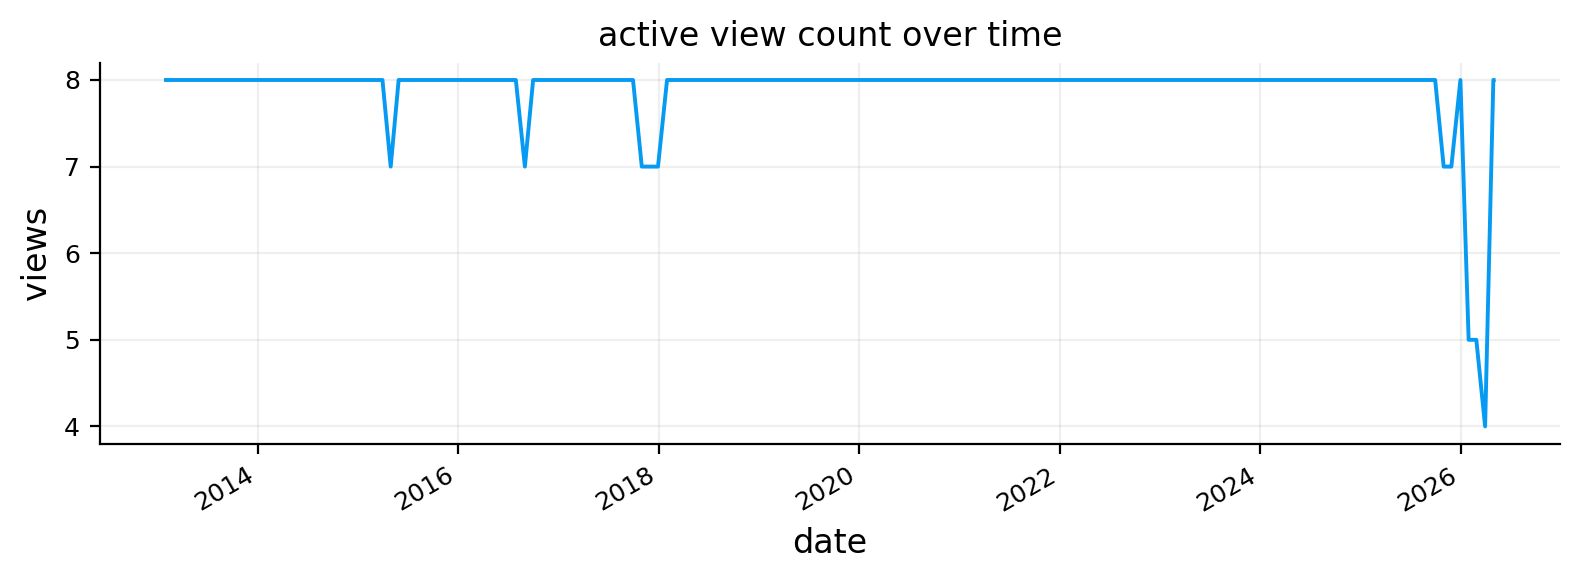

,view_family,view_name,economic_label,long_assets,short_assets,signal_value,q,risk_orientation,source
0,commodities_vs_bonds_pair,DBC over AGG,automatic pair-spread view,[DBC],[AGG],1.4005,0.0469,neutral,systematic
1,real_assets_vs_bonds,real assets over bonds,gold/commodity hedge versus core bonds,"[GLD, DBC]","[AGG, IEF]",1.0699,0.0399,neutral,interpretable
2,trend_breadth,risk breadth over defensive basket,market breadth and risk participation,"[DBC, EEM, IWM]","[GLD, SHY, AGG]",1.0000,0.0381,risk_on,systematic
3,gold_vs_bonds_pair,GLD over AGG,automatic pair-spread view,[GLD],[AGG],0.6612,0.0275,neutral,systematic
4,credit_risk_appetite,HYG over LQD,high-yield credit versus investment-grade credit,[HYG],[LQD],0.4256,0.0185,risk_on,interpretable
5,equity_vs_duration_pair,SPY over TLT,automatic pair-spread view,[SPY],[TLT],0.5006,0.0215,risk_on,systematic
6,equity_vs_gold_pair,GLD over SPY,automatic pair-spread view,[GLD],[SPY],-0.4817,0.0208,risk_off,systematic
7,em_vs_developed_pair,EEM over EFA,automatic pair-spread view,[EEM],[EFA],0.4241,0.0185,neutral,systematic


,active_count,avg_abs_q,avg_signal_strength
view_family,,,
equity_vs_duration_pair,119,0.0440,1.4043
equity_vs_gold_pair,110,0.0444,1.4431
duration_defense,105,0.0374,1.0407
commodities_vs_bonds_pair,94,0.0450,1.4583
gold_vs_bonds_pair,85,0.0409,1.1888
real_assets_vs_bonds,80,0.0384,1.0970
small_cap_vs_market,79,0.0380,1.0438
international_vs_us,76,0.0381,1.0617
reit_rates_sensitivity,71,0.0357,0.9750


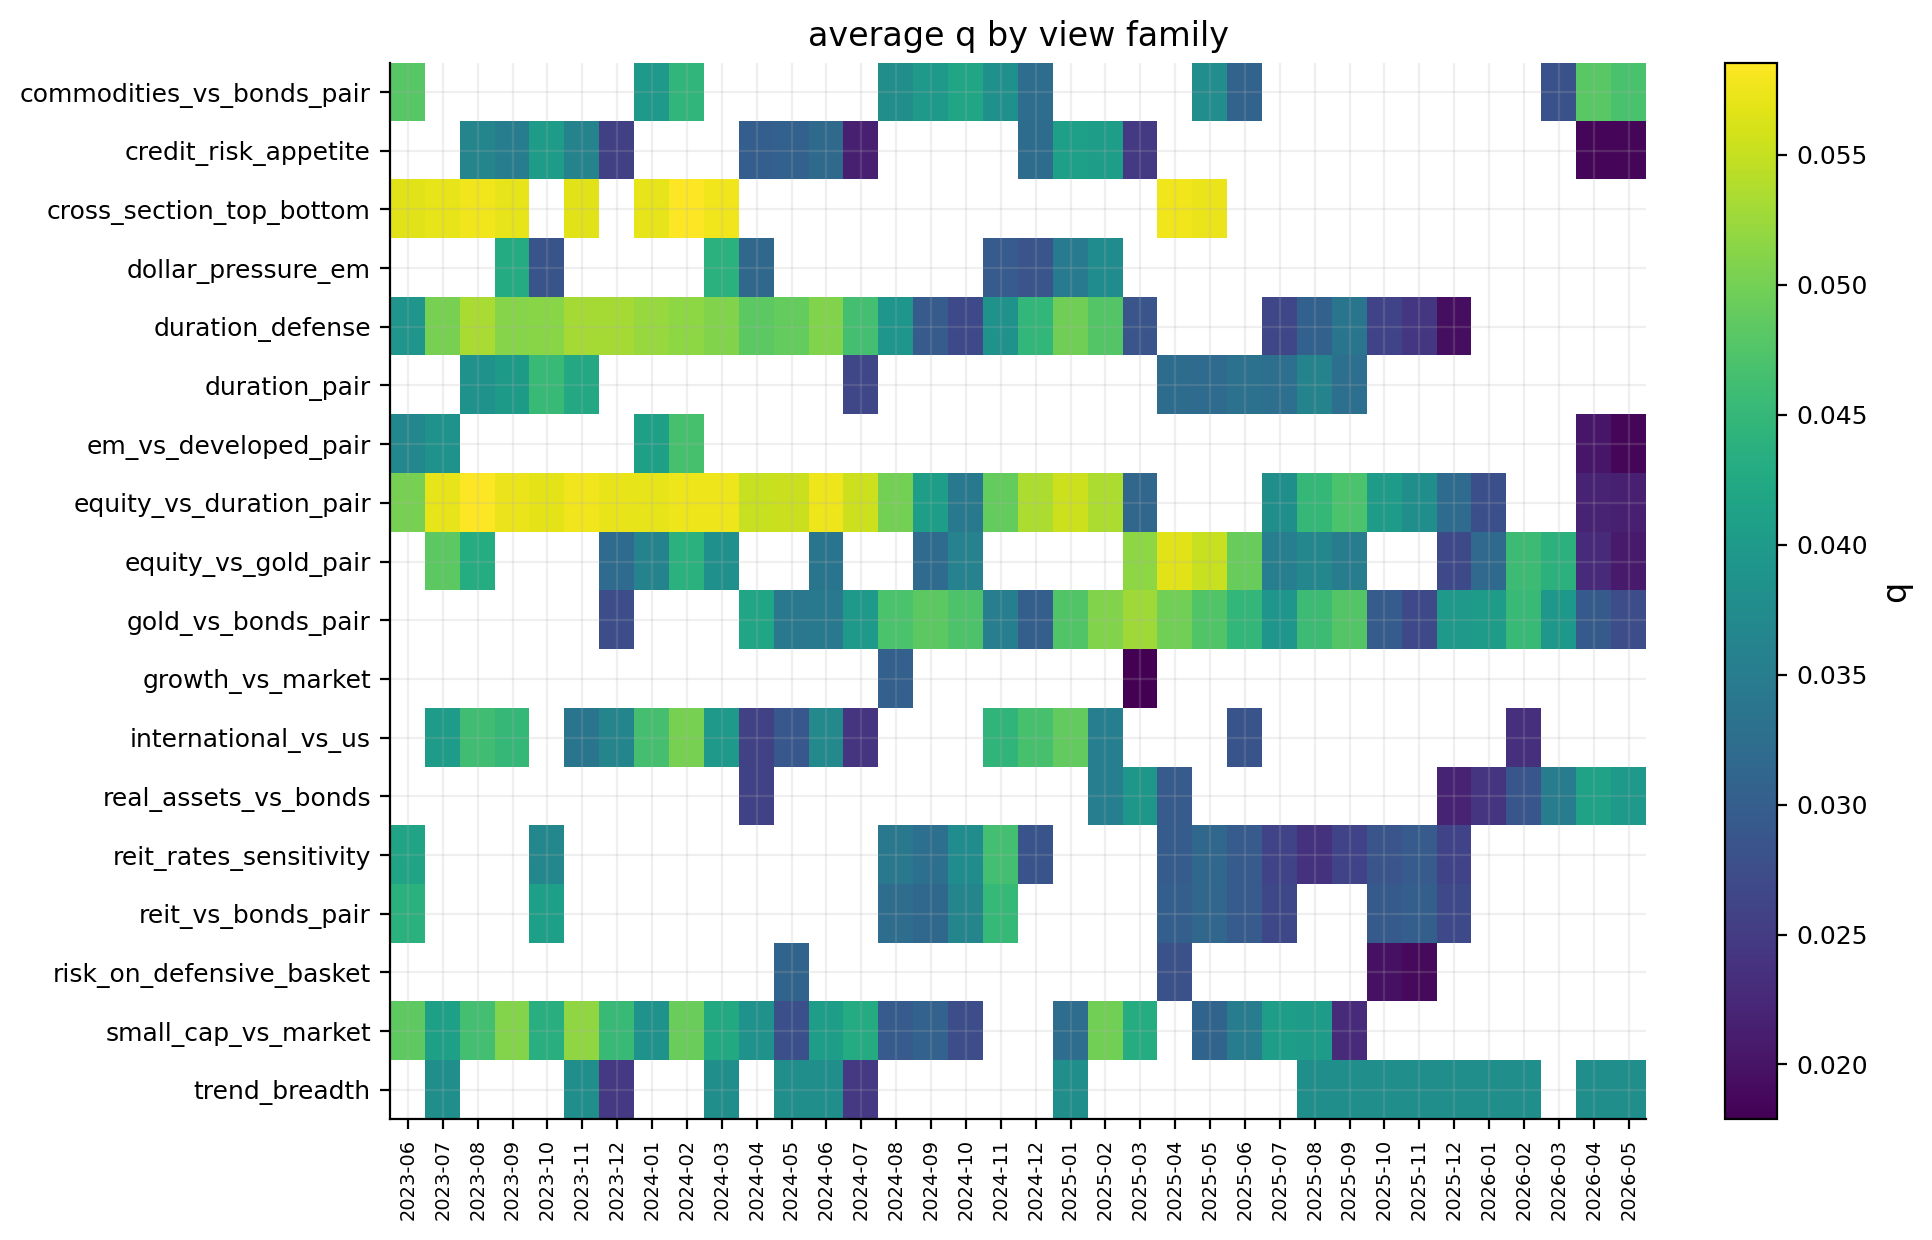

In [20]:
view_cache = {}
view_log_rows = []
top_bottom_spread_history = []
for dt in rebalance_dates:
    signal_table, market_state = compute_asset_signals(signal_close, signal_returns, dt)
    simple_views = make_simple_interpretable_views(signal_table, market_state)
    systematic_signals = make_systematic_signal_table(signal_table, market_state)
    snapshot = top_bottom_spread_snapshot(signal_table)
    cross_ok, cross_threshold = cross_section_is_active(snapshot, top_bottom_spread_history)
    systematic_views = make_systematic_views(signal_table, market_state, simple_views, cross_section_active=cross_ok)
    active_views = combine_and_rank_views(simple_views, systematic_views)
    view_cache[pd.Timestamp(dt)] = {"asset_signal_table": signal_table, "market_state": market_state, "simple_views": simple_views, "systematic_signals": systematic_signals, "systematic_views": systematic_views, "active_views": active_views, "top_bottom_spread": snapshot.get("spread", np.nan), "top_bottom_threshold": cross_threshold, "cross_section_active": cross_ok}
    top_bottom_spread_history.append(snapshot.get("spread", np.nan))
    for row in active_views:
        rec = dict(row); rec["date"] = pd.Timestamp(dt); view_log_rows.append(rec)
view_preview_log = pd.DataFrame(view_log_rows)
active_count_series = view_preview_log.groupby("date").size().reindex(rebalance_dates, fill_value=0) if not view_preview_log.empty else pd.Series(0, index=rebalance_dates)
ax = active_count_series.plot(figsize=(8, 3), lw=1.4)
ax.set_title("active view count over time"); ax.set_ylabel("views"); ax.set_xlabel("date")
plt.tight_layout(); plt.show()
latest_active_views = view_cache[pd.Timestamp(latest_rebalance_date)]["active_views"]
latest_active_table = pd.DataFrame(latest_active_views)
if not latest_active_table.empty:
    display(latest_active_table[["view_family", "view_name", "economic_label", "long_assets", "short_assets", "signal_value", "q", "risk_orientation", "source"]].round(4))
else:
    print("no active views on the latest rebalance date")
if not view_preview_log.empty:
    family_frequency = view_preview_log.groupby("view_family").agg(active_count=("view_name", "size"), avg_abs_q=("q", lambda x: np.mean(np.abs(x))), avg_signal_strength=("signal_value", lambda x: np.mean(np.abs(x)))).sort_values("active_count", ascending=False)
    display(family_frequency.round(4))
    q_heatmap = view_preview_log.groupby(["view_family", "date"])["q"].mean().unstack().iloc[:, -36:]
    fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(q_heatmap))))
    im = ax.imshow(q_heatmap, aspect="auto", cmap="viridis")
    ax.set_title("average q by view family"); ax.set_yticks(range(len(q_heatmap.index)), q_heatmap.index)
    ax.set_xticks(range(len(q_heatmap.columns)), [d.strftime("%Y-%m") for d in q_heatmap.columns], rotation=90, fontsize=7)
    fig.colorbar(im, ax=ax, label="q"); plt.tight_layout(); plt.show()


In [21]:
def build_view_matrix(active_views, assets, prior_mu=None, payoff_history=None, current_date=None, use_learned_q=True):
    clean_rows, view_p_rows, view_q_vals = [], [], []
    asset_index = {asset: i for i, asset in enumerate(assets)}
    prior = pd.Series(prior_mu, index=assets, dtype=float).reindex(assets).fillna(0.0) if prior_mu is not None else pd.Series(0.0, index=assets)
    broad_families = {"cross_section_top_bottom", "risk_on_defensive_basket", "trend_breadth"}
    for row in active_views:
        long_assets = [x for x in row.get("long_assets", []) if x in asset_index]
        short_assets = [x for x in row.get("short_assets", []) if x in asset_index]
        if not long_assets or not short_assets:
            continue
        p_row = np.zeros(len(assets), dtype=float)
        for asset in long_assets:
            p_row[asset_index[asset]] += 1.0 / len(long_assets)
        for asset in short_assets:
            p_row[asset_index[asset]] -= 1.0 / len(short_assets)
        if abs(p_row.sum()) > 1e-8:
            print("warning: p row does not sum close to zero", row.get("view_name"), p_row.sum())
        tilt_cap = view_tilt_max_systematic if row.get("view_family") in broad_families else view_tilt_max
        raw_q_tilt = float(tilt_cap * math.tanh(0.75 * abs(row.get("signal_value", 0.0))))
        if use_learned_q:
            q_info = learned_q_for_view(row, payoff_history, current_date, raw_q_tilt, tilt_cap)
            if q_info.get("q_dropped", False):
                continue
            q_tilt = float(q_info["q_tilt_learned"])
        else:
            q_info = {"q_tilt_learned": raw_q_tilt, "q_shrink": np.nan, "q_dropped": False, "q_model": "raw signal tilt", "n_obs": np.nan, "avg_payoff": np.nan, "payoff_ir": np.nan, "t_stat": np.nan, "info_coefficient": np.nan}
            q_tilt = raw_q_tilt
        reliability_multiplier = float(row.get("reliability_multiplier", 1.0))
        q_tilt_final = q_tilt * reliability_multiplier
        base_view_spread = float(p_row @ prior.values)
        q_val = base_view_spread + q_tilt_final
        expression_parts = [f"{1.0 / len(long_assets):.2f}*{asset}" for asset in long_assets] + [f"-{1.0 / len(short_assets):.2f}*{asset}" for asset in short_assets]
        rec = dict(row)
        rec["economic_theme"] = view_theme(rec)
        rec["base_view_spread"] = base_view_spread
        rec["raw_q_tilt"] = raw_q_tilt
        rec["q_tilt"] = q_tilt
        rec["reliability_multiplier"] = reliability_multiplier
        rec["q_tilt_final"] = q_tilt_final
        rec["q"] = q_val
        rec["q_model"] = q_info.get("q_model", "")
        rec["q_shrink"] = q_info.get("q_shrink", np.nan)
        rec["q_n_obs"] = q_info.get("n_obs", np.nan)
        rec["q_payoff_ir"] = q_info.get("payoff_ir", np.nan)
        rec["q_t_stat"] = q_info.get("t_stat", np.nan)
        rec["q_info_coefficient"] = q_info.get("info_coefficient", np.nan)
        rec["p_expression"] = " + ".join(expression_parts).replace("+ -", "- ")
        clean_rows.append(rec)
        view_p_rows.append(p_row)
        view_q_vals.append(q_val)
    view_p = np.vstack(view_p_rows) if view_p_rows else np.empty((0, len(assets)))
    view_q = np.asarray(view_q_vals, dtype=float)
    clean_view_table = pd.DataFrame(clean_rows)
    assert view_p.shape[1] == len(assets)
    return view_p, view_q, clean_view_table

latest_view_p, latest_view_q, latest_clean_view_table = build_view_matrix(latest_active_views, assets, prior_mu_by_date[pd.Timestamp(latest_rebalance_date)], use_learned_q=False)
print("view_p shape:", latest_view_p.shape, "view_q shape:", latest_view_q.shape)
if not latest_clean_view_table.empty:
    display(latest_clean_view_table[["view_name", "long_assets", "short_assets", "base_view_spread", "raw_q_tilt", "q_tilt_final", "q", "p_expression"]].round(4))


view_p shape: (8, 18) view_q shape: (8,)


,view_name,long_assets,short_assets,base_view_spread,raw_q_tilt,q_tilt_final,q,p_expression
0,DBC over AGG,[DBC],[AGG],-0.1242,0.0235,0.0235,-0.1007,1.00*DBC - 1.00*AGG
1,real assets over bonds,"[GLD, DBC]","[AGG, IEF]",-0.0017,0.0200,0.0200,0.0183,0.50*GLD + 0.50*DBC - 0.50*AGG - 0.50*IEF
2,risk breadth over defensive basket,"[DBC, EEM, IWM]","[GLD, SHY, AGG]",0.0237,0.0095,0.0095,0.0332,0.33*DBC + 0.33*EEM + 0.33*IWM - 0.33*GLD - 0....
3,GLD over AGG,[GLD],[AGG],0.1240,0.0138,0.0138,0.1378,1.00*GLD - 1.00*AGG
4,HYG over LQD,[HYG],[LQD],0.0012,0.0093,0.0093,0.0104,1.00*HYG - 1.00*LQD
5,SPY over TLT,[SPY],[TLT],0.0706,0.0108,0.0108,0.0813,1.00*SPY - 1.00*TLT
6,GLD over SPY,[GLD],[SPY],0.0401,0.0104,0.0104,0.0504,1.00*GLD - 1.00*SPY
7,EEM over EFA,[EEM],[EFA],0.0479,0.0092,0.0092,0.0571,1.00*EEM - 1.00*EFA


In [22]:
def p_row_from_view(row, assets):
    p = pd.Series(0.0, index=assets, dtype=float)
    long_assets = [x for x in row.get("long_assets", []) if x in p.index]
    short_assets = [x for x in row.get("short_assets", []) if x in p.index]
    if not long_assets or not short_assets:
        return None
    p.loc[long_assets] = 1.0 / len(long_assets)
    p.loc[short_assets] = -1.0 / len(short_assets)
    return p

def build_view_payoff_history(view_log, returns, horizon=view_horizon_days):
    if view_log.empty:
        return pd.DataFrame()
    rows = []
    for _, row in view_log.iterrows():
        dt = pd.Timestamp(row["date"])
        pos = returns.index.searchsorted(dt, side="right") - 1
        if pos < 0 or pos + horizon >= len(returns.index):
            continue
        forward_asset_return = (1.0 + returns.iloc[pos + 1:pos + horizon + 1]).prod() - 1.0
        p = p_row_from_view(row, returns.columns)
        if p is None:
            continue
        payoff = float(p @ forward_asset_return.reindex(p.index).fillna(0.0))
        rows.append({"date": dt, "payoff_end_date": returns.index[pos + horizon], "view_family": row["view_family"], "view_name": row["view_name"], "economic_theme": view_theme(row), "signal_value": row["signal_value"], "signal_strength": abs(row["signal_value"]), "q": row.get("q", np.nan), "payoff": payoff, "hit": payoff > 0, "risk_orientation": row["risk_orientation"], "economic_label": row["economic_label"]})
    return pd.DataFrame(rows)

all_payoff_history = build_view_payoff_history(view_preview_log, returns_p6[assets])
print("payoff observations:", len(all_payoff_history))
print("confidence now uses payoff mean, volatility, t-stat, information coefficient, sign stability, recent decay, and sample size")

confidence_preview_rows = []
for mode in ["fixed", "learned", "haircut"]:
    for row in latest_active_views:
        details = confidence_for_view(row, all_payoff_history, latest_rebalance_date, latest_market_state, mode)
        confidence_preview_rows.append({"date": pd.Timestamp(latest_rebalance_date), "view_family": row["view_family"], "view_name": row["view_name"], "confidence_mode": "full_" + mode, "confidence": details["confidence"], "hit_rate": details["hit_rate"], "recent_hit_rate": details["recent_hit_rate"], "payoff_ir": details["payoff_ir"], "t_stat": details["t_stat"], "info_coefficient": details["info_coefficient"], "n_obs": details["n_obs"], "haircut_multiplier": details["haircut_multiplier"], "risk_orientation": details["risk_orientation"]})
for mode in ["learned", "haircut"]:
    for row in latest_active_views:
        details = scaled_confidence_for_view(row, all_payoff_history, latest_rebalance_date, latest_market_state, mode)
        confidence_preview_rows.append({"date": pd.Timestamp(latest_rebalance_date), "view_family": row["view_family"], "view_name": row["view_name"], "confidence_mode": "scaled_" + mode, "confidence": details["confidence"], "hit_rate": details["hit_rate"], "recent_hit_rate": details["recent_hit_rate"], "payoff_ir": details["payoff_ir"], "t_stat": details["t_stat"], "info_coefficient": details["info_coefficient"], "n_obs": details["n_obs"], "haircut_multiplier": details["haircut_multiplier"], "risk_orientation": details["risk_orientation"]})
confidence_preview = pd.DataFrame(confidence_preview_rows)
display(confidence_preview.groupby(["confidence_mode", "view_family"])["confidence"].mean().unstack(0).round(4))


payoff observations: 1255
confidence now uses payoff mean, volatility, t-stat, information coefficient, sign stability, recent decay, and sample size


confidence_mode,full_fixed,full_haircut,full_learned,scaled_haircut,scaled_learned
view_family,,,,,
commodities_vs_bonds_pair,0.5,0.3860,0.5147,0.3860,0.5147
credit_risk_appetite,0.5,0.3415,0.4553,0.3415,0.4553
em_vs_developed_pair,0.5,0.4774,0.4774,0.4774,0.4774
equity_vs_duration_pair,0.5,0.5553,0.5553,0.5553,0.5553
equity_vs_gold_pair,0.5,0.4863,0.4863,0.4863,0.4863
gold_vs_bonds_pair,0.5,0.6023,0.6023,0.6023,0.6023
real_assets_vs_bonds,0.5,0.6478,0.6478,0.6478,0.6478
trend_breadth,0.5,0.5861,0.5861,0.5861,0.5861


In [23]:
def omega_from_confidence(view_p, cov_ann, confidence, full_view_cov=True):
    if len(confidence) == 0 or view_p.shape[0] == 0:
        return np.empty((0, 0)), np.array([])
    conf = np.asarray(confidence, dtype=float)
    conf = np.where(np.isfinite(conf), conf, 0.50)
    conf = np.maximum(conf, 1e-4)
    cov_arr = np.asarray(cov_ann, dtype=float)
    view_cov = view_p @ cov_arr @ view_p.T
    view_cov = 0.5 * (view_cov + view_cov.T)
    view_var = np.maximum(np.diag(view_cov), 1e-8)
    try:
        scale = np.sqrt((1.0 - conf) / conf)
        omega = tau * np.diag(scale) @ view_cov @ np.diag(scale)
        omega = 0.5 * (omega + omega.T)
        omega = omega + np.eye(len(conf)) * 1e-8
        if np.all(np.isfinite(omega)):
            return omega, view_var
    except Exception:
        pass
    omega_diag = ((1.0 - conf) / conf) * tau * view_var
    omega_diag = np.maximum(omega_diag, 1e-8)
    return np.diag(omega_diag), view_var

if latest_view_p.shape[0] > 0:
    learned_conf = [confidence_for_view(row, all_payoff_history, latest_rebalance_date, latest_market_state, "learned")["confidence"] for row in latest_clean_view_table.to_dict("records")]
    latest_omega, latest_view_var = omega_from_confidence(latest_view_p, cov_by_date[pd.Timestamp(latest_rebalance_date)].loc[assets, assets], learned_conf)
    omega_table = latest_clean_view_table[["view_name", "view_family", "raw_q_tilt", "q_tilt_final", "q"]].copy()
    omega_table["confidence"] = learned_conf
    omega_table["view_variance"] = latest_view_var
    omega_table["omega_diag"] = np.diag(latest_omega)
    display(omega_table.round(6))
    print("omega uses the full view covariance matrix; the diagonal shown here is only for readability")
else:
    print("no active views for omega display")


,view_name,view_family,raw_q_tilt,q_tilt_final,q,confidence,view_variance,omega_diag
0,DBC over AGG,commodities_vs_bonds_pair,0.023458,0.023458,-0.100701,0.514667,0.064554,0.003044
1,real assets over bonds,real_assets_vs_bonds,0.019961,0.019961,0.018269,0.647804,0.026382,0.000717
2,risk breadth over defensive basket,trend_breadth,0.009527,0.009527,0.033231,0.586075,0.011536,0.000407
3,GLD over AGG,gold_vs_bonds_pair,0.013766,0.013766,0.137802,0.602286,0.064440,0.002128
4,HYG over LQD,credit_risk_appetite,0.009264,0.009264,0.010415,0.455268,0.000934,0.000056
5,SPY over TLT,equity_vs_duration_pair,0.010762,0.010762,0.081335,0.555263,0.018150,0.000727
6,GLD over SPY,equity_vs_gold_pair,0.010390,0.010390,0.050447,0.486293,0.056948,0.003008
7,EEM over EFA,em_vs_developed_pair,0.009232,0.009232,0.057130,0.477373,0.015229,0.000834


omega uses the full view covariance matrix; the diagonal shown here is only for readability


In [24]:
def black_litterman_posterior(prior_mu, cov_ann, view_p, view_q, omega, tau=tau):
    prior_mu = pd.Series(prior_mu).astype(float)
    cov_ann = pd.DataFrame(cov_ann, index=prior_mu.index, columns=prior_mu.index).astype(float)
    diag = {"n_views": int(view_p.shape[0]), "avg_confidence": np.nan, "max_confidence": np.nan, "min_confidence": np.nan, "max_abs_q": float(np.max(np.abs(view_q))) if len(view_q) else 0.0, "max_abs_posterior_shift": 0.0, "condition_number": np.nan, "no_views": view_p.shape[0] == 0, "failure": False, "clipped": False}
    if view_p.shape[0] == 0:
        return prior_mu.copy(), cov_ann.copy(), diag
    try:
        cov_arr = make_psd_df(cov_ann.values, cov_ann.index).values
        tau_cov = tau * cov_arr
        omega_arr = np.asarray(omega, dtype=float)
        omega_arr = 0.5 * (omega_arr + omega_arr.T) + np.eye(view_p.shape[0]) * 1e-8
        middle = view_p @ tau_cov @ view_p.T + omega_arr
        middle = 0.5 * (middle + middle.T) + np.eye(view_p.shape[0]) * 1e-10
        view_gap = view_q - view_p @ prior_mu.values
        diag["condition_number"] = float(np.linalg.cond(middle))
        solved_gap = np.linalg.solve(middle, view_gap)
        post_mu_arr = prior_mu.values + tau_cov @ view_p.T @ solved_gap
        solved_cov = np.linalg.solve(middle, view_p @ tau_cov)
        posterior_uncertainty = tau_cov - tau_cov @ view_p.T @ solved_cov
        post_cov_arr = local_make_psd(cov_arr + posterior_uncertainty)
        clipped = np.any((post_mu_arr < -0.30) | (post_mu_arr > 0.30))
        post_mu_arr = np.clip(post_mu_arr, -0.30, 0.30)
        post_mu = pd.Series(post_mu_arr, index=prior_mu.index)
        post_cov = pd.DataFrame(post_cov_arr, index=prior_mu.index, columns=prior_mu.index)
        diag["clipped"] = bool(clipped)
        diag["max_abs_posterior_shift"] = float(np.max(np.abs(post_mu.values - prior_mu.values)))
        return post_mu, post_cov, diag
    except Exception:
        diag["failure"] = True
        return prior_mu.copy(), cov_ann.copy(), diag

def diagnostic_bl_weights(post_mu, post_cov, delta_t):
    try:
        raw = pd.Series(np.linalg.solve(delta_t * post_cov.values, post_mu.values), index=post_mu.index)
        return normalize_box_weights(raw.clip(lower=0.0), post_mu.index, lower=w_min, upper=w_max)
    except Exception:
        return benchmark_w.copy()

if latest_view_p.shape[0] > 0:
    post_mu_sample, post_cov_sample, post_diag_sample = black_litterman_posterior(prior_mu_by_date[pd.Timestamp(latest_rebalance_date)], cov_by_date[pd.Timestamp(latest_rebalance_date)].loc[assets, assets], latest_view_p, latest_view_q, latest_omega)
else:
    post_mu_sample, post_cov_sample, post_diag_sample = black_litterman_posterior(prior_mu_by_date[pd.Timestamp(latest_rebalance_date)], cov_by_date[pd.Timestamp(latest_rebalance_date)].loc[assets, assets], latest_view_p, latest_view_q, np.empty((0, 0)))
prior_post_table = pd.DataFrame({"asset": assets, "prior_mu": prior_mu_by_date[pd.Timestamp(latest_rebalance_date)].reindex(assets).values, "post_mu": post_mu_sample.reindex(assets).values, "shift": post_mu_sample.reindex(assets).values - prior_mu_by_date[pd.Timestamp(latest_rebalance_date)].reindex(assets).values}).sort_values("shift", ascending=False)
display(prior_post_table.round(4))
diagnostic_w = diagnostic_bl_weights(post_mu_sample, post_cov_sample, delta_by_date[pd.Timestamp(latest_rebalance_date)])
display(pd.DataFrame({"asset": diagnostic_w.index, "diagnostic_bl_implied_weight": diagnostic_w.values}).sort_values("diagnostic_bl_implied_weight", ascending=False).round(4))
print(post_diag_sample)


,asset,prior_mu,post_mu,shift
17,DBC,-0.0996,-0.0740,0.0256
13,GLD,0.1486,0.1597,0.0111
14,GDX,0.2980,0.3000,0.0020
8,SHY,0.0090,0.0081,-0.0009
12,HYG,0.0360,0.0342,-0.0018
5,EEM,0.2058,0.2039,-0.0019
2,IWM,0.1471,0.1441,-0.0031
9,AGG,0.0246,0.0210,-0.0036
10,BND,0.0237,0.0201,-0.0036
1,QQQ,0.1335,0.1296,-0.0039


,asset,diagnostic_bl_implied_weight
12,HYG,0.1782
6,TLT,0.1782
9,AGG,0.0921
15,VNQ,0.0824
3,EFA,0.0789
5,EEM,0.0752
13,GLD,0.0746
8,SHY,0.0696
2,IWM,0.0626
1,QQQ,0.0585


{'n_views': 8, 'avg_confidence': nan, 'max_confidence': nan, 'min_confidence': nan, 'max_abs_q': 0.13780208759319507, 'max_abs_posterior_shift': 0.025560362072412357, 'condition_number': 751.1606211812165, 'no_views': False, 'failure': False, 'clipped': True}


In [25]:
def clean_bl_weight_array(weights, index, previous=None):
    caps = asset_caps.reindex(index).fillna(w_max)
    if weights is None:
        weights = previous if previous is not None else benchmark_w.reindex(index).values
    w = pd.Series(np.asarray(weights, dtype=float).reshape(-1), index=index)
    if len(w) != len(index) or not np.all(np.isfinite(w)):
        w = pd.Series(previous, index=index) if previous is not None else benchmark_w.reindex(index).fillna(0.0)
    w = w.clip(lower=w_min, upper=caps)
    if w.sum() <= 1e-12:
        w = benchmark_w.reindex(index).fillna(0.0).clip(upper=caps)
    w = w / w.sum()
    for _ in range(100):
        over = w > caps + 1e-12
        if not over.any():
            break
        extra = float((w[over] - caps[over]).sum())
        w[over] = caps[over]
        room = (caps[~over] - w[~over]).clip(lower=0.0)
        if room.sum() <= 1e-12:
            break
        w.loc[room.index] += extra * room / room.sum()
    w = w.clip(lower=w_min, upper=caps)
    return (w / w.sum()).to_numpy(dtype=float)

def cvxpy_bl_optimizer(mu, cov_ann, w_prev=None, active_limit=active_weight_limit, use_sleeves=True, te_gamma=0.0):
    if cp is None:
        return None
    index = list(mu.index)
    n = len(index)
    w_var = cp.Variable(n)
    cov_arr = local_make_psd(cov_ann.values + np.eye(n) * 1e-8)
    caps = asset_caps.reindex(index).fillna(w_max).to_numpy(dtype=float)
    bench = benchmark_w.reindex(index).fillna(0.0).to_numpy(dtype=float)
    prev = np.asarray(w_prev if w_prev is not None else bench, dtype=float)
    turnover_penalty = cost_bps / 10000.0 * cp.norm1(w_var - prev)
    te_penalty = te_gamma * cp.quad_form(w_var - bench, cov_arr) if te_gamma and te_gamma > 0 else 0.0
    objective = cp.Maximize(mu.values @ w_var - 0.5 * bl_mv_lambda * cp.quad_form(w_var, cov_arr) - turnover_penalty - te_penalty)
    constraints = [cp.sum(w_var) == 1.0, w_var >= w_min, w_var <= caps]
    if active_limit is not None:
        constraints += [w_var - bench <= active_limit, bench - w_var <= active_limit]
    if use_sleeves:
        for sleeve, spec in sleeve_constraints.items():
            locs = [index.index(asset) for asset in spec["assets"] if asset in index]
            if locs:
                sleeve_weight = cp.sum(w_var[locs])
                constraints += [sleeve_weight >= spec["min"], sleeve_weight <= spec["max"]]
    problem = cp.Problem(objective, constraints)
    for solver in ["CLARABEL", "OSQP", "ECOS", "SCS"]:
        problem.solve(solver=solver, verbose=False)
        if w_var.value is not None and problem.status in ["optimal", "optimal_inaccurate"]:
            return np.asarray(w_var.value, dtype=float)


def optimize_bl_weights(post_mu, post_cov, w_prev=None):
    attempts = [
        {"active_limit": active_weight_limit, "use_sleeves": True, "te_gamma": 0.0},
        {"active_limit": active_weight_relaxed, "use_sleeves": True, "te_gamma": 0.0},
        {"active_limit": active_weight_limit, "use_sleeves": False, "te_gamma": 0.0},
        {"active_limit": active_weight_relaxed, "use_sleeves": False, "te_gamma": 0.0},
        {"active_limit": None, "use_sleeves": False, "te_gamma": gamma_te},
    ]
    for attempt in attempts:
        w = cvxpy_bl_optimizer(post_mu, post_cov, w_prev=w_prev, **attempt)
        if w is not None:
            return clean_bl_weight_array(w, post_mu.index, previous=w_prev), False, attempt
    previous = w_prev if w_prev is not None else benchmark_w.reindex(post_mu.index).values
    return clean_bl_weight_array(previous, post_mu.index, previous=previous), True, {"active_limit": None, "use_sleeves": False, "te_gamma": np.nan}


def apply_benchmark_relative_risk_control(weights, cov_ann):
    w_bl = pd.Series(weights, index=assets, dtype=float).reindex(assets).fillna(0.0)
    bench = benchmark_w.reindex(assets).fillna(0.0)
    cov_arr = cov_ann.loc[assets, assets].values
    vol_bl = float(np.sqrt(max(w_bl.values @ cov_arr @ w_bl.values, 0.0)))
    vol_bench = float(np.sqrt(max(bench.values @ cov_arr @ bench.values, 0.0)))
    target_vol = max(0.08, vol_bench)
    if np.isfinite(vol_bl) and vol_bl > target_vol and vol_bl > 1e-12:
        alpha = min(1.0, target_vol / vol_bl)
        w_final = alpha * w_bl + (1.0 - alpha) * bench
    else:
        w_final = w_bl
    return clean_bl_weight_array(w_final.values, assets, previous=bench.values), {"vol_bl": vol_bl, "vol_bench": vol_bench, "target_vol": target_vol}


In [26]:
bl_modes = {
    "BL full-view learned": {"view_set": "full", "confidence_mode": "learned", "risk_control": False},
    "BL full-view haircut": {"view_set": "full", "confidence_mode": "haircut", "risk_control": False},
    "BL scaled-view learned": {"view_set": "scaled", "confidence_mode": "learned", "risk_control": False},
    "BL scaled-view haircut": {"view_set": "scaled", "confidence_mode": "haircut", "risk_control": False},
    "BL scaled-view risk-controlled": {"view_set": "scaled", "confidence_mode": "learned", "risk_control": True},
}
bl_weight_rows = {name: [] for name in bl_modes}
bl_fallback_rows = {name: [] for name in bl_modes}
bl_prev_weights = {name: None for name in bl_modes}
confidence_log_rows = []
posterior_log_rows = []
full_view_log_rows = []
scaled_view_log_rows = []
scaling_log_rows = []
post_mu_store = {}
post_cov_store = {}

for i, dt in enumerate(rebalance_dates[:-1]):
    dt = pd.Timestamp(dt)
    cache = view_cache[dt]
    full_views = cache["active_views"]
    market_state = cache["market_state"]
    prior_mu = prior_mu_by_date[dt].reindex(assets)
    cov_ann = cov_by_date[dt].loc[assets, assets]
    payoff_history_now = all_payoff_history[all_payoff_history["payoff_end_date"] < dt].copy() if not all_payoff_history.empty else pd.DataFrame()
    full_view_p, full_view_q, full_clean_table = build_view_matrix(full_views, assets, prior_mu, payoff_history=payoff_history_now, current_date=dt, use_learned_q=True)
    if not full_clean_table.empty:
        full_view_log_rows.extend(full_clean_table.assign(date=dt, view_set="full", strategy="full-view").to_dict("records"))

    scaled_cache = {}
    for strategy_name, spec in bl_modes.items():
        view_set = spec["view_set"]
        mode = spec["confidence_mode"]
        if view_set == "scaled":
            cache_key = mode
            if cache_key not in scaled_cache:
                scaled_views, scale_rows = select_scaled_views(full_views, payoff_history_now, dt, market_state, mode)
                scaling_log_rows.extend(scale_rows)
                scaled_view_p, scaled_view_q, scaled_clean_table = build_view_matrix(scaled_views, assets, prior_mu, payoff_history=payoff_history_now, current_date=dt, use_learned_q=True)
                scaled_cache[cache_key] = (scaled_view_p, scaled_view_q, scaled_clean_table)
                if mode == "learned" and not scaled_clean_table.empty:
                    scaled_view_log_rows.extend(scaled_clean_table.assign(date=dt, view_set="scaled", strategy="BL scaled-view learned").to_dict("records"))
            view_p, view_q, clean_table = scaled_cache[cache_key]
        else:
            view_p, view_q, clean_table = full_view_p, full_view_q, full_clean_table

        rows_for_posterior = clean_table.to_dict("records") if not clean_table.empty else []
        conf_values = []
        for row in rows_for_posterior:
            if view_set == "scaled":
                details = {"confidence": row.get("confidence", np.nan), "hit_rate": row.get("hit_rate", np.nan), "recent_hit_rate": row.get("recent_hit_rate", np.nan), "payoff_ir": row.get("payoff_ir", np.nan), "t_stat": row.get("t_stat", np.nan), "info_coefficient": row.get("info_coefficient", np.nan), "n_obs": row.get("n_obs", np.nan), "haircut_multiplier": 1.0}
            else:
                details = confidence_for_view(row, payoff_history_now, dt, market_state, mode)
            conf_values.append(details["confidence"] if np.isfinite(details["confidence"]) else 0.50)
            confidence_log_rows.append({"date": dt, "view_set": view_set, "strategy": strategy_name, "view_family": row["view_family"], "view_name": row["view_name"], "economic_theme": view_theme(row), "confidence_mode": mode, "confidence": details["confidence"], "reliability_multiplier": row.get("reliability_multiplier", 1.0 if view_set == "full" else np.nan), "hit_rate": details["hit_rate"], "recent_hit_rate": details["recent_hit_rate"], "payoff_ir": details["payoff_ir"], "t_stat": details.get("t_stat", np.nan), "info_coefficient": details.get("info_coefficient", np.nan), "n_obs": details["n_obs"], "haircut_multiplier": details.get("haircut_multiplier", 1.0), "risk_orientation": row["risk_orientation"]})
        omega, view_var = omega_from_confidence(view_p, cov_ann, conf_values, full_view_cov=True)
        post_mu, post_cov, diag = black_litterman_posterior(prior_mu, cov_ann, view_p, view_q, omega)
        if conf_values:
            diag["avg_confidence"] = float(np.mean(conf_values)); diag["max_confidence"] = float(np.max(conf_values)); diag["min_confidence"] = float(np.min(conf_values))
        diag.update({"date": dt, "strategy": strategy_name, "view_set": view_set, "confidence_mode": mode})
        posterior_log_rows.append(diag)
        post_mu_store[(strategy_name, dt)] = post_mu
        post_cov_store[(strategy_name, dt)] = post_cov
        w_prev = bl_prev_weights[strategy_name]
        w_new, fallback, opt_info = optimize_bl_weights(post_mu, post_cov, w_prev=w_prev)
        w_new = clean_bl_weight_array(w_new, assets, previous=w_prev)
        if spec.get("risk_control", False):
            w_new, risk_control_info = apply_benchmark_relative_risk_control(w_new, cov_ann)
        bl_weight_rows[strategy_name].append(pd.Series(w_new, index=assets, name=dt))
        bl_fallback_rows[strategy_name].append((dt, int(bool(fallback or diag.get("failure", False)))))
        bl_prev_weights[strategy_name] = w_new

bl_weight_schedules = {name: pd.DataFrame(rows) for name, rows in bl_weight_rows.items()}
bl_fallback_flags = {name: pd.Series(dict(rows), dtype=float).sort_index() for name, rows in bl_fallback_rows.items()}
bl_backtests = run_many_weights_backtests(
    bl_weight_schedules,
    returns=returns_p6[assets],
    cost_bps=cost_bps,
    w_min=w_min,
    w_max=None,
    long_only=True,
    normalize=True,
    weight_timing="next_close",
)
bl_results = {name: backtest_result_to_dict(name, result, bl_fallback_flags[name]) for name, result in bl_backtests.items()}
view_log = pd.DataFrame(full_view_log_rows)
scaled_view_log = pd.DataFrame(scaled_view_log_rows)
scaling_log = pd.DataFrame(scaling_log_rows)
confidence_log = pd.DataFrame(confidence_log_rows)
posterior_log = pd.DataFrame(posterior_log_rows)
print("bl strategies finished:", list(bl_results))
print("full view rows:", len(view_log), "scaled view rows:", len(scaled_view_log), "confidence rows:", len(confidence_log), "posterior rows:", len(posterior_log))


bl strategies finished: ['BL full-view learned', 'BL full-view haircut', 'BL scaled-view learned', 'BL scaled-view haircut', 'BL scaled-view risk-controlled']
full view rows: 1081 scaled view rows: 675 confidence rows: 4187 posterior rows: 800


In [27]:
combined_results = {}
combined_results.update(baseline_results)
combined_results.update(bl_results)
final_strategy_names = [
    "Equal Weight", "MaxSharpe_FG_EWMA_Mom", "EWMA Momentum MV",
    "BL full-view learned",
    "BL full-view haircut",
    "BL scaled-view learned",
    "BL scaled-view haircut",
    "BL scaled-view risk-controlled"]

returns_by_strategy = {name: combined_results[name]["returns"] for name in final_strategy_names}
nav_by_strategy = {name: combined_results[name]["nav"] for name in final_strategy_names}
weights_by_strategy = {name: combined_results[name]["weights"] for name in final_strategy_names}
turnover_by_strategy = {name: combined_results[name]["turnover"] for name in final_strategy_names}
cost_by_strategy = {name: combined_results[name]["costs"] for name in final_strategy_names}

def cagr_from_nav(nav):
    nav = pd.Series(nav).dropna()
    if nav.empty:
        return np.nan
    years = max(len(nav) / annualization, 1e-9)
    return float(nav.iloc[-1] ** (1.0 / years) - 1.0)

gross_net_rows = []
for name in final_strategy_names:
    result = combined_results[name]
    gross_net_rows.append({
        "strategy": name,
        "Gross CAGR": cagr_from_nav(result.get("gross_nav", result["nav"])),
        "Net CAGR": cagr_from_nav(result["nav"]),
        "Cost Drag": float(result["costs"].sum()) if len(result["costs"]) else np.nan,
        "Average Monthly Turnover": float(result["turnover"].mean()) if len(result["turnover"]) else np.nan,
        "Total Turnover": float(result["turnover"].sum()) if len(result["turnover"]) else np.nan})
    
gross_net_table = pd.DataFrame(gross_net_rows).set_index("strategy")
display(gross_net_table.round(4))

def full_strategy_metrics(name, result):
    ret = pd.Series(result["returns"]).dropna(); nav = pd.Series(result["nav"]).dropna()
    if ret.empty:
        return {"strategy": name}
    years = max(len(nav) / annualization, 1e-9)
    cagr = float(nav.iloc[-1] ** (1.0 / years) - 1.0)
    ann_vol = float(ret.std(ddof=1) * math.sqrt(annualization))
    sharpe = float((ret.mean() - risk_free_daily) / ret.std(ddof=1) * math.sqrt(annualization)) if ret.std(ddof=1) > 1e-12 else np.nan
    downside = ret[ret < risk_free_daily]
    sortino = float((ret.mean() - risk_free_daily) / downside.std(ddof=1) * math.sqrt(annualization)) if len(downside) > 2 and downside.std(ddof=1) > 1e-12 else np.nan
    max_dd = max_drawdown_from_nav(nav)
    weights = result["weights"]
    eff_n = float((1.0 / weights.pow(2).sum(axis=1)).replace([np.inf, -np.inf], np.nan).mean()) if not weights.empty else np.nan
    avg_max_weight = float(weights.max(axis=1).mean()) if not weights.empty else np.nan
    return {"strategy": name, "CAGR": cagr, "Annualized Volatility": ann_vol, "Sharpe": sharpe, "Sortino": sortino, "Max Drawdown": max_dd, "Calmar": cagr / abs(max_dd) if max_dd < 0 else np.nan, "Avg Monthly Turnover": float(result["turnover"].mean()) if len(result["turnover"]) else np.nan, "Total Turnover": float(result["turnover"].sum()) if len(result["turnover"]) else np.nan, "Cost Drag": float(result["costs"].sum()) if len(result["costs"]) else np.nan, "Effective Number of Holdings": eff_n, "Average Max Weight": avg_max_weight, "Fallback Count": result.get("fallback_count", 0)}

summary_table = pd.DataFrame([full_strategy_metrics(name, combined_results[name]) for name in final_strategy_names]).set_index("strategy")
display(summary_table.round(4))
print("full-view BL is diagnostic; scaled-view BL is closer to a live rule because learned q and confidence use only rolling historical view payoffs")


,Gross CAGR,Net CAGR,Cost Drag,Average Monthly Turnover,Total Turnover
strategy,,,,,
Equal Weight,0.0674,0.0672,0.0033,0.0156,2.4904
MaxSharpe_FG_EWMA_Mom,0.0902,0.0860,0.0862,0.3210,51.3590
EWMA Momentum MV,0.0465,0.0443,0.0342,0.1704,27.2695
BL full-view learned,0.0795,0.0780,0.0302,0.1163,18.6005
BL full-view haircut,0.0803,0.0787,0.0311,0.1177,18.8328
BL scaled-view learned,0.0784,0.0773,0.0208,0.0796,12.7287
BL scaled-view haircut,0.0776,0.0765,0.0210,0.0810,12.9606
BL scaled-view risk-controlled,0.0769,0.0758,0.0221,0.0852,13.6295


,CAGR,Annualized Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Avg Monthly Turnover,Total Turnover,Cost Drag,Effective Number of Holdings,Average Max Weight,Fallback Count
strategy,,,,,,,,,,,,
Equal Weight,0.0672,0.0975,0.7139,0.8942,-0.2154,0.3121,0.0156,2.4904,0.0033,18.0000,0.0556,0
MaxSharpe_FG_EWMA_Mom,0.0860,0.1070,0.8227,0.9892,-0.1977,0.4349,0.3210,51.3590,0.0862,4.5286,0.2500,0
EWMA Momentum MV,0.0443,0.0492,0.9075,1.1295,-0.1373,0.3230,0.1704,27.2695,0.0342,4.8285,0.2495,0
BL full-view learned,0.0780,0.1116,0.7263,0.8673,-0.2479,0.3146,0.1163,18.6005,0.0302,6.3444,0.2792,0
BL full-view haircut,0.0787,0.1097,0.7428,0.8921,-0.2455,0.3207,0.1177,18.8328,0.0311,6.4501,0.2726,0
BL scaled-view learned,0.0773,0.1071,0.7464,0.8972,-0.2440,0.3169,0.0796,12.7287,0.0208,6.7218,0.2769,0
BL scaled-view haircut,0.0765,0.1068,0.7412,0.8900,-0.2450,0.3123,0.0810,12.9606,0.0210,6.8855,0.2705,0
BL scaled-view risk-controlled,0.0758,0.1041,0.7514,0.9052,-0.2418,0.3135,0.0852,13.6295,0.0221,7.4271,0.2635,0


full-view BL is diagnostic; scaled-view BL is closer to a live rule because learned q and confidence use only rolling historical view payoffs


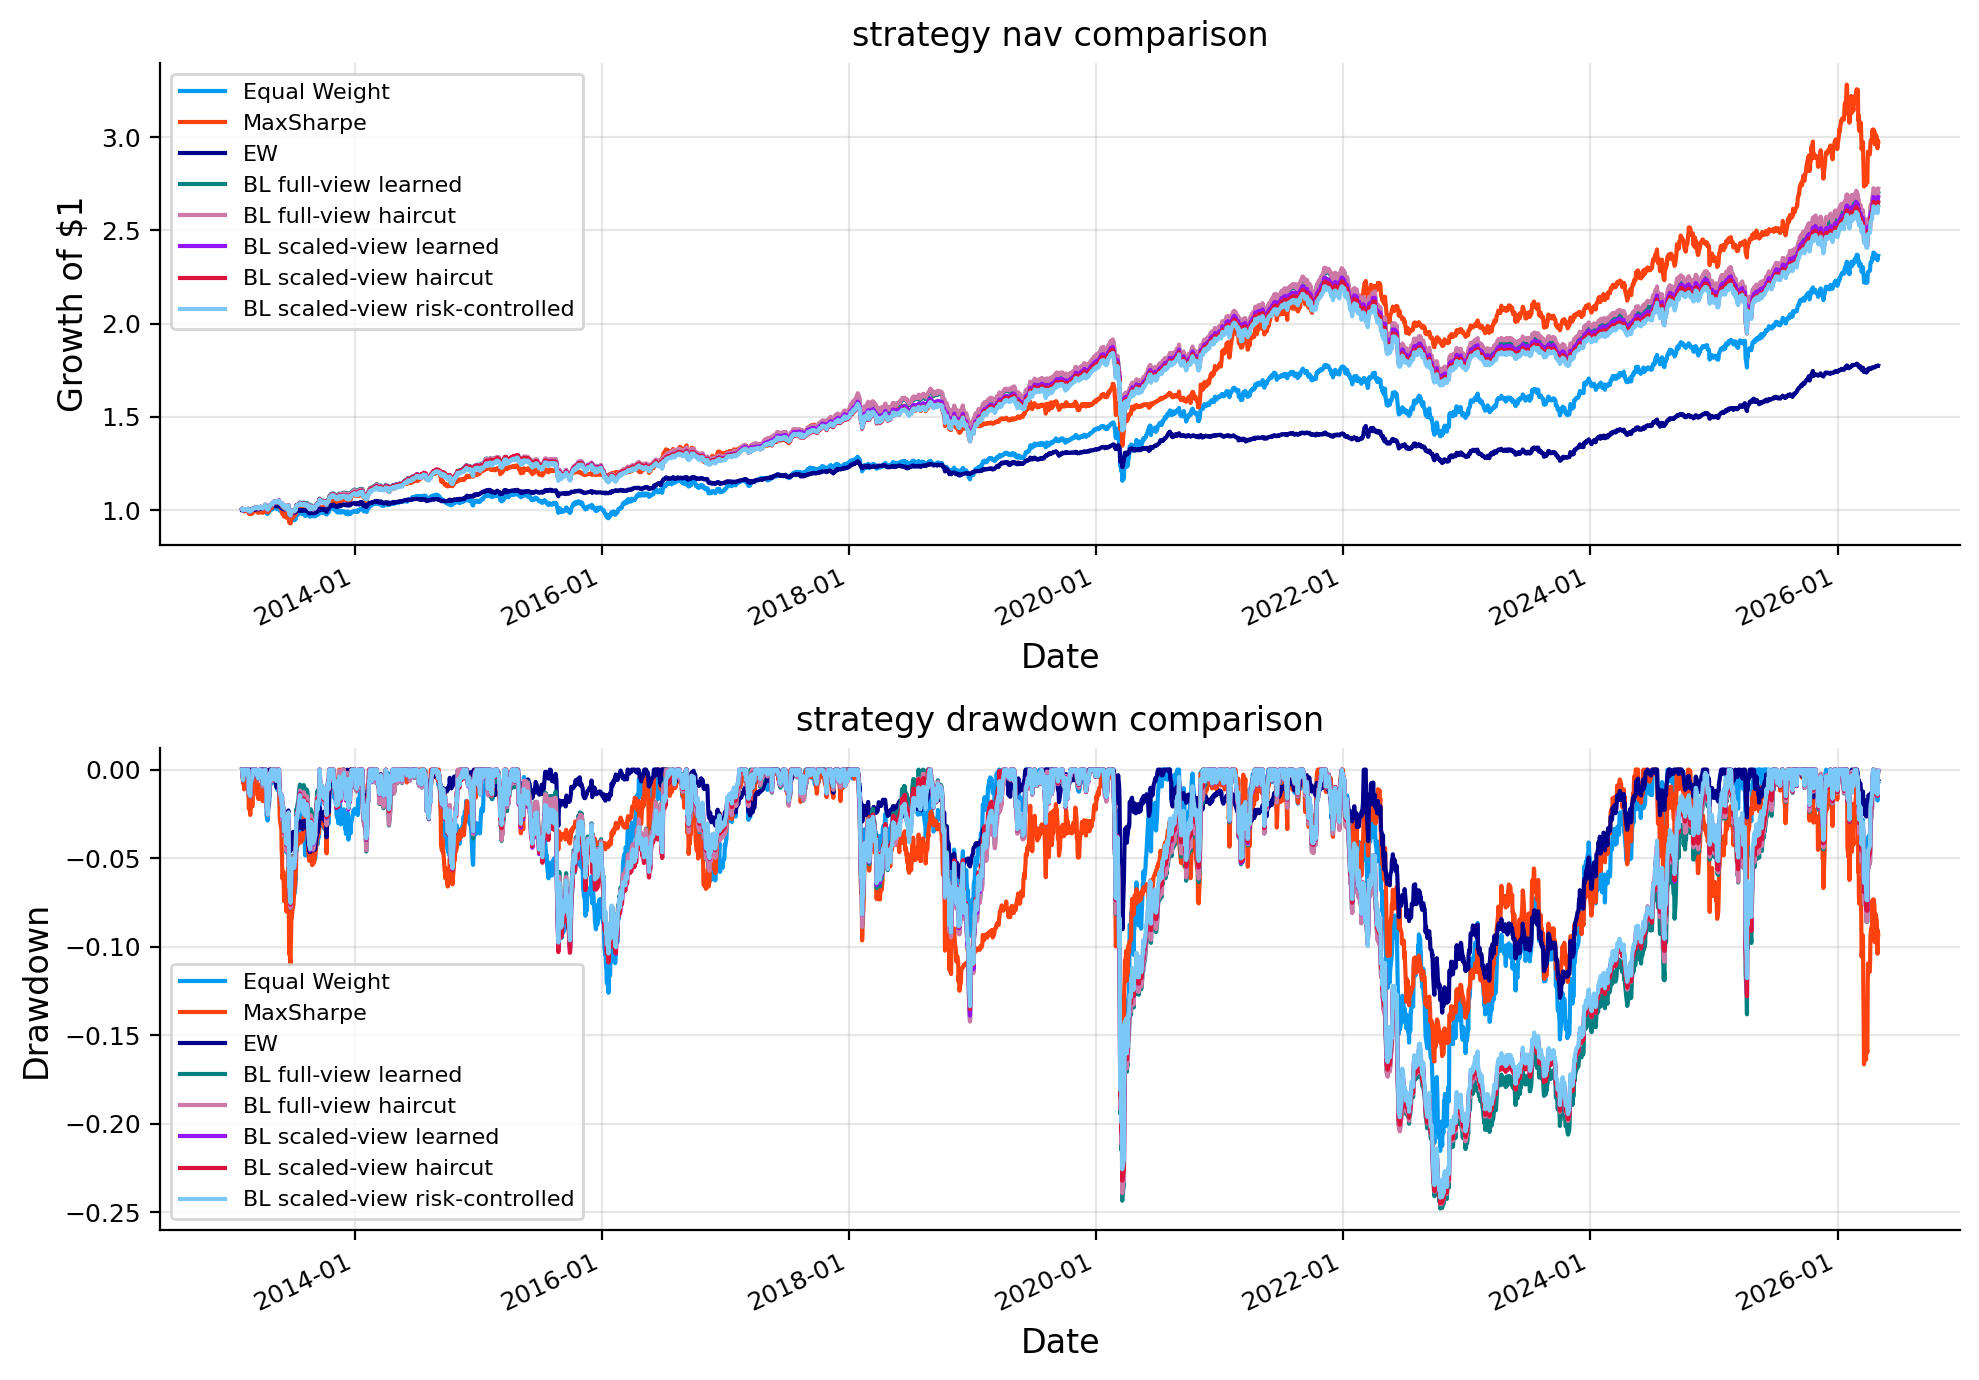

In [28]:
nav_df = pd.DataFrame(nav_by_strategy)[final_strategy_names]
drawdown_df = nav_df / nav_df.cummax() - 1.0
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
plot_strategy_nav(nav_df, final_strategy_names, ax=axes[0], title="strategy nav comparison")
plot_strategy_drawdowns(nav_df, final_strategy_names, ax=axes[1], title="strategy drawdown comparison")
plt.tight_layout()
plt.show()


,max_dd,longest_dd_days,avg_recovery_days,ulcer_index
object,,,,
BL full-view haircut,-0.2455,819,17.3471,0.0773
BL full-view learned,-0.2479,910,17.8970,0.0797
BL scaled-view haircut,-0.2450,786,16.1319,0.0767
BL scaled-view learned,-0.2440,786,16.0273,0.0764
BL scaled-view risk-controlled,-0.2418,785,15.9511,0.0749
EWMA Momentum MV,-0.1373,572,21.1295,0.0379
Equal Weight,-0.2154,664,19.0256,0.0553
MaxSharpe_FG_EWMA_Mom,-0.1977,594,21.5036,0.0545


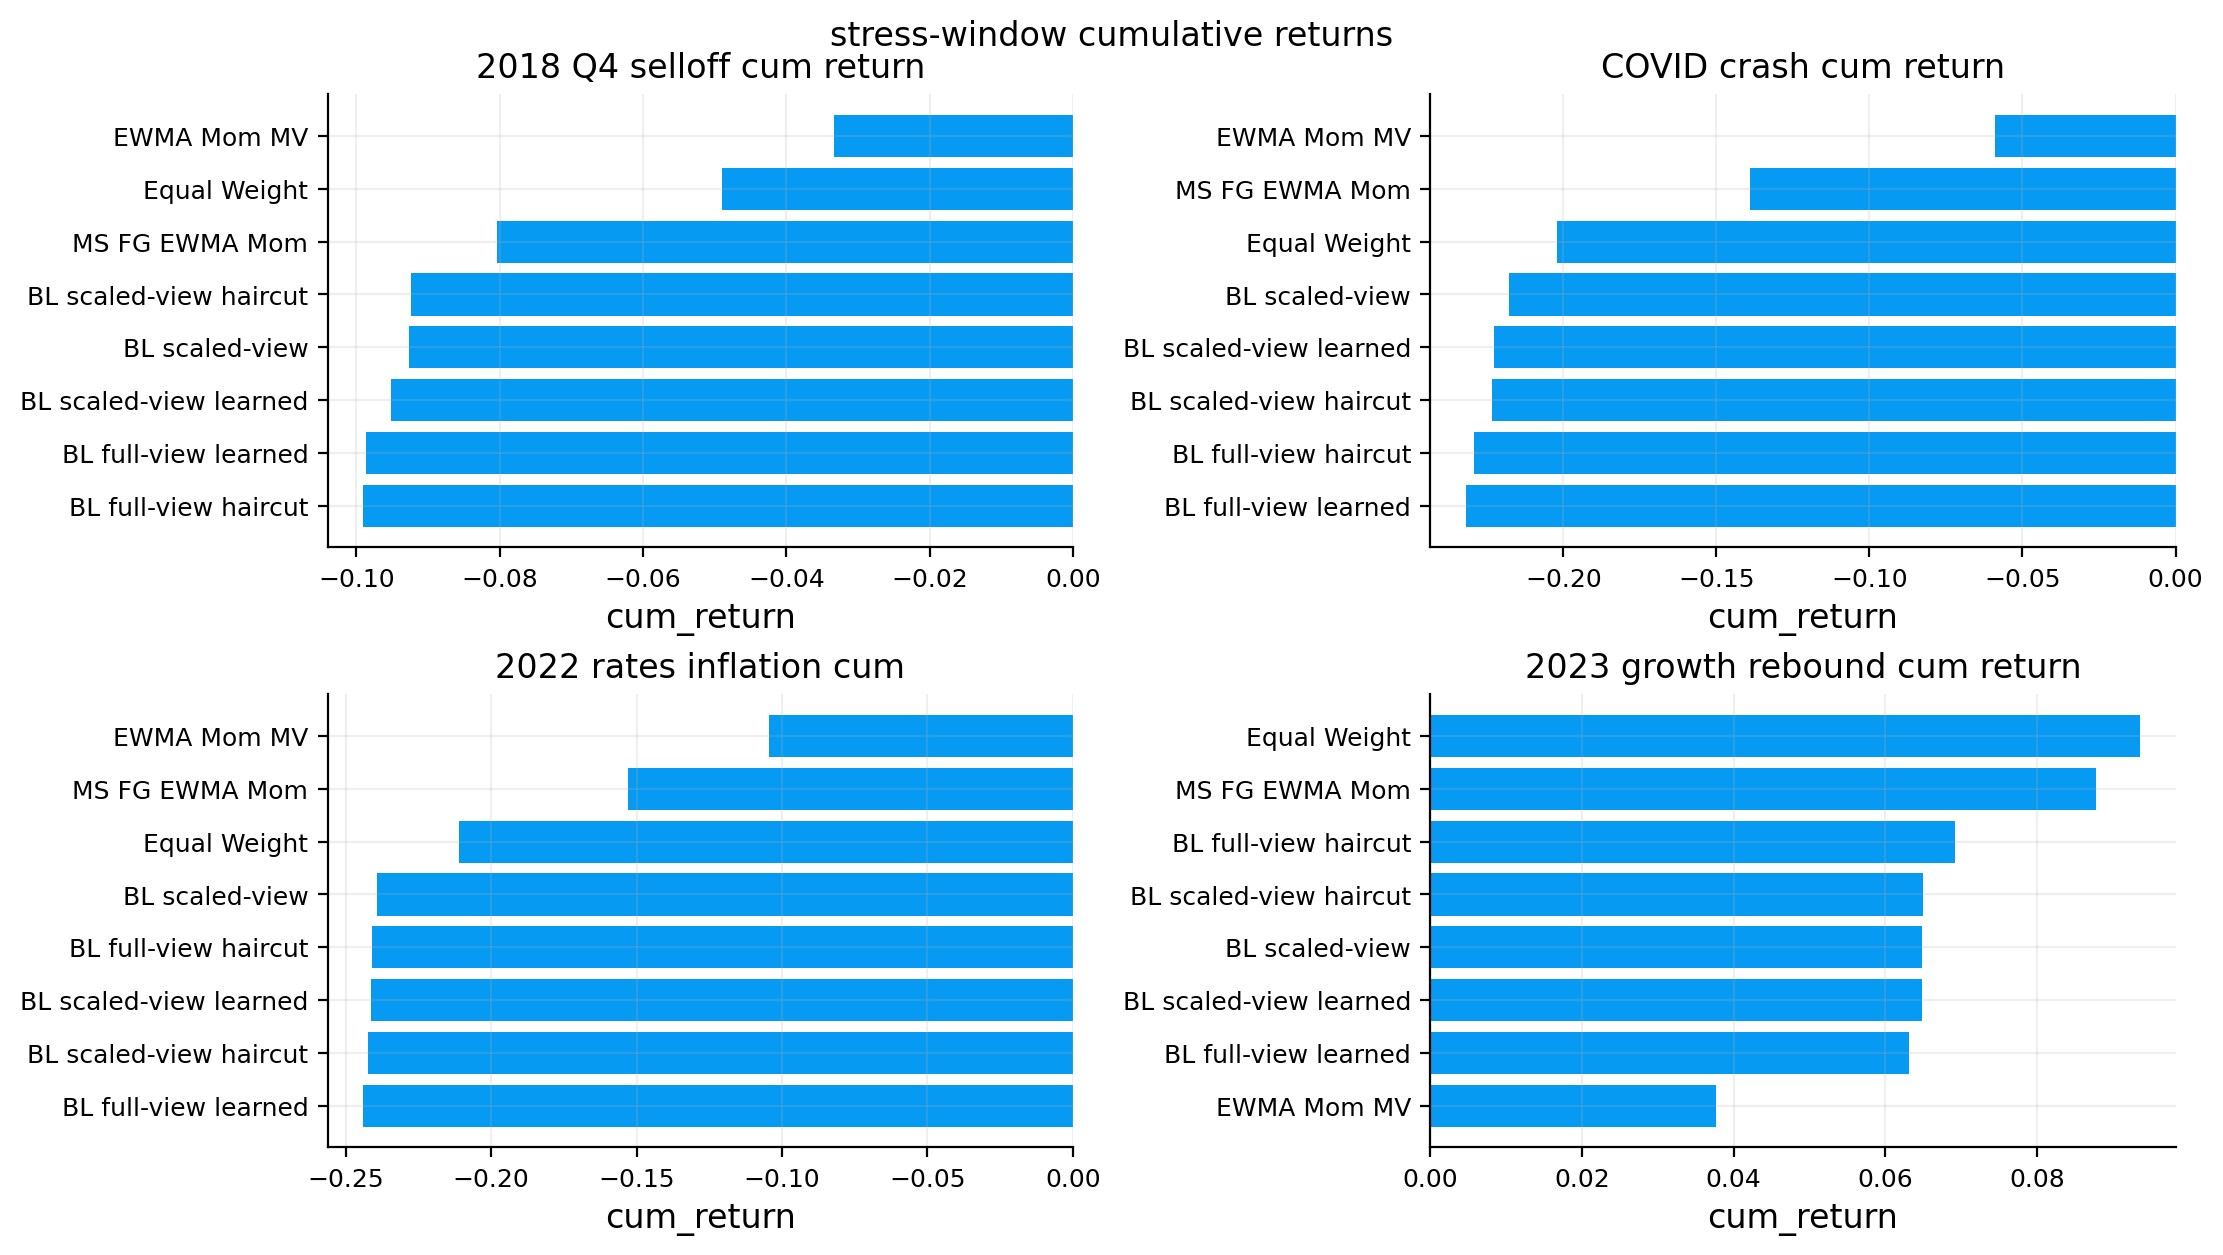

,hist_var5,hist_es5,fhs_var5,fhs_es5
object,,,,
BL full-view haircut,0.0102,0.0168,0.0153,0.0231
BL full-view learned,0.0105,0.0172,0.0153,0.0232
BL scaled-view haircut,0.0098,0.0163,0.0148,0.0224
BL scaled-view learned,0.0099,0.0164,0.0148,0.0224
BL scaled-view risk-controlled,0.0096,0.0159,0.0139,0.0212
EWMA Momentum MV,0.0046,0.0073,0.0039,0.0059
Equal Weight,0.0090,0.0143,0.0123,0.0181
MaxSharpe_FG_EWMA_Mom,0.0104,0.0171,0.0251,0.0383


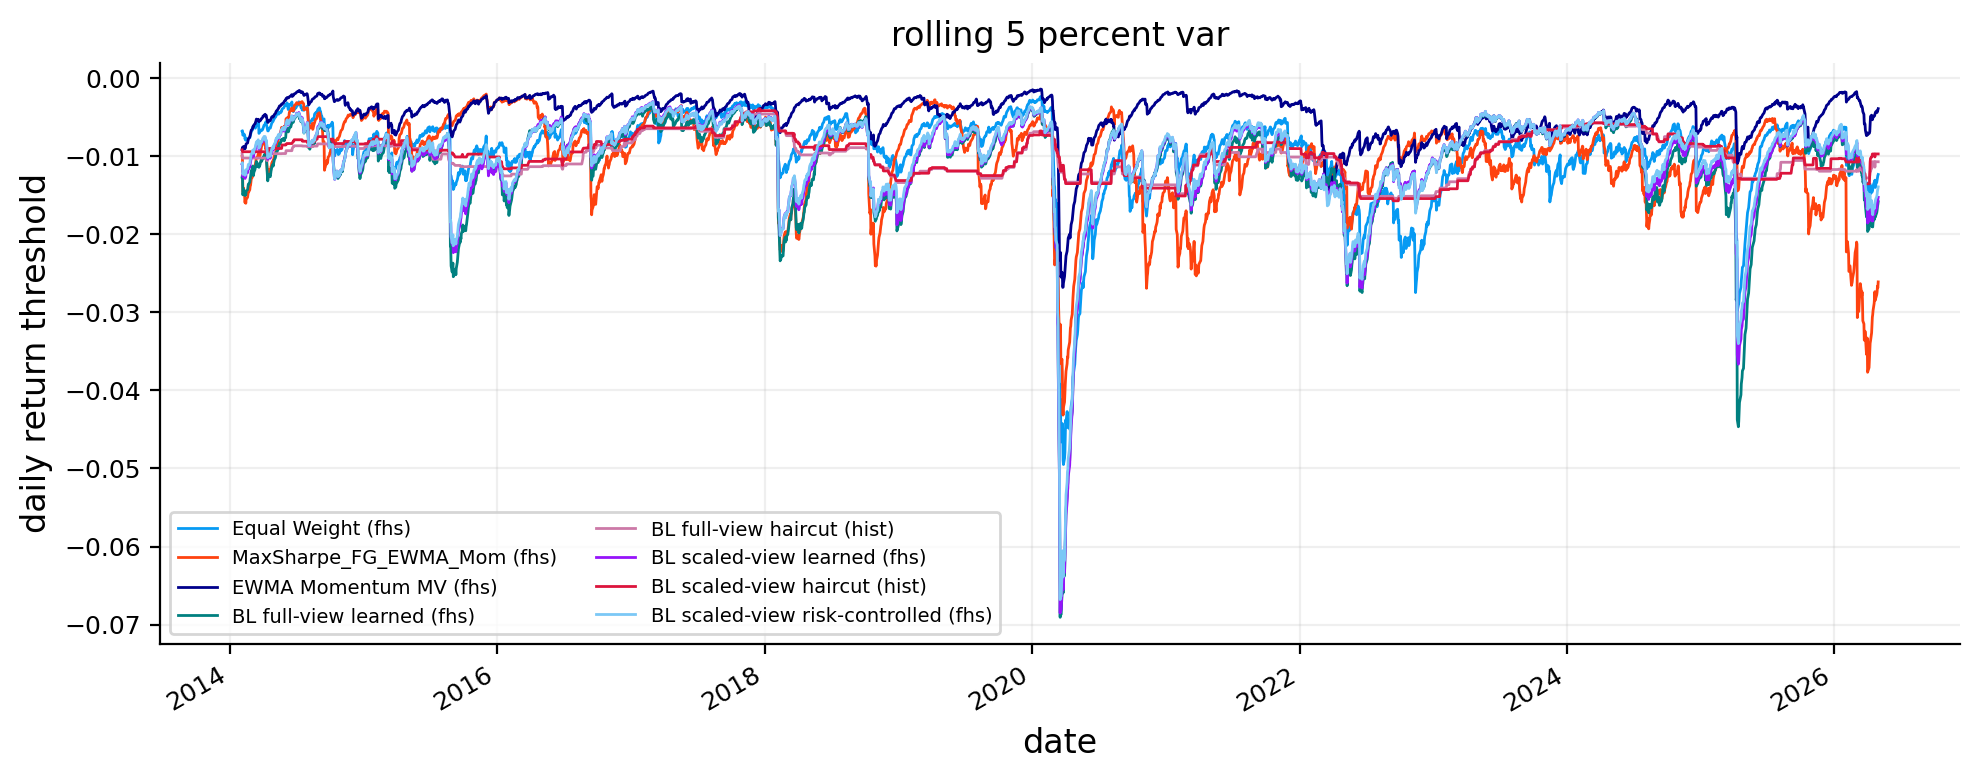

In [29]:
final_returns_df = pd.DataFrame(returns_by_strategy)[final_strategy_names].dropna(how="all").fillna(0.0)

drawdown_summary = drawdown_summary_table(final_returns_df)
if drawdown_summary.empty:
    rows = []
    for name in final_strategy_names:
        nav = simple_nav(final_returns_df[name]); dd = simple_drawdown(nav)
        rows.append({"strategy": name, "max_drawdown": dd.min(), "date_of_max_drawdown": dd.idxmin(), "current_drawdown": dd.iloc[-1], "average_drawdown": dd.mean()})
    drawdown_summary = pd.DataFrame(rows).set_index("strategy")
display(drawdown_summary.round(4))

stress_windows = {"2018_Q4_selloff": ("2018-10-01", "2018-12-31"), "COVID_crash": ("2020-02-19", "2020-03-23"), "2022_rates_inflation": ("2022-01-03", "2022-10-14"), "2023_growth_rebound": ("2023-01-01", "2023-07-31")}
stress_result = stress_table(final_returns_df, windows=stress_windows, worst_only=False)
fig, axes = plt.subplots(2, 2, figsize=(11, 6), constrained_layout=True)
for ax, window in zip(axes.ravel(), stress_windows.keys()):
    plot_stress_bar(ax, stress_result, window=window, metric="cum_return", ascending=True)
fig.suptitle("stress-window cumulative returns", y=1.02)
plt.show()

var_es = var_es_table(final_returns_df, alpha=0.05, methods=("hist", "fhs"))
display(var_es.round(4))

best_var_method = {name: "fhs" for name in final_strategy_names}
var_backtest_internal = var_backtest_table(final_returns_df, alpha=0.05, methods=("hist", "cf", "fhs"), lookback=252)
picked = best_var_methods(var_backtest_internal)
if isinstance(picked, dict):
    best_var_method.update({k: picked.get(k, "fhs") for k in final_strategy_names})

fig, ax = plt.subplots(figsize=(10, 4))
for name in final_strategy_names:
    method = best_var_method.get(name, "fhs")
    method = method if method in ["hist", "cf", "fhs"] else "fhs"
    rv = rolling_var(final_returns_df[name], alpha=0.05, lookback=252, method=method)
    rv.plot(ax=ax, lw=1.0, label=f"{name} ({method})")
    
ax.set_title("rolling 5 percent var"); ax.set_ylabel("daily return threshold"); ax.set_xlabel("date"); ax.legend(ncol=2, fontsize=7)
plt.tight_layout()
plt.show()


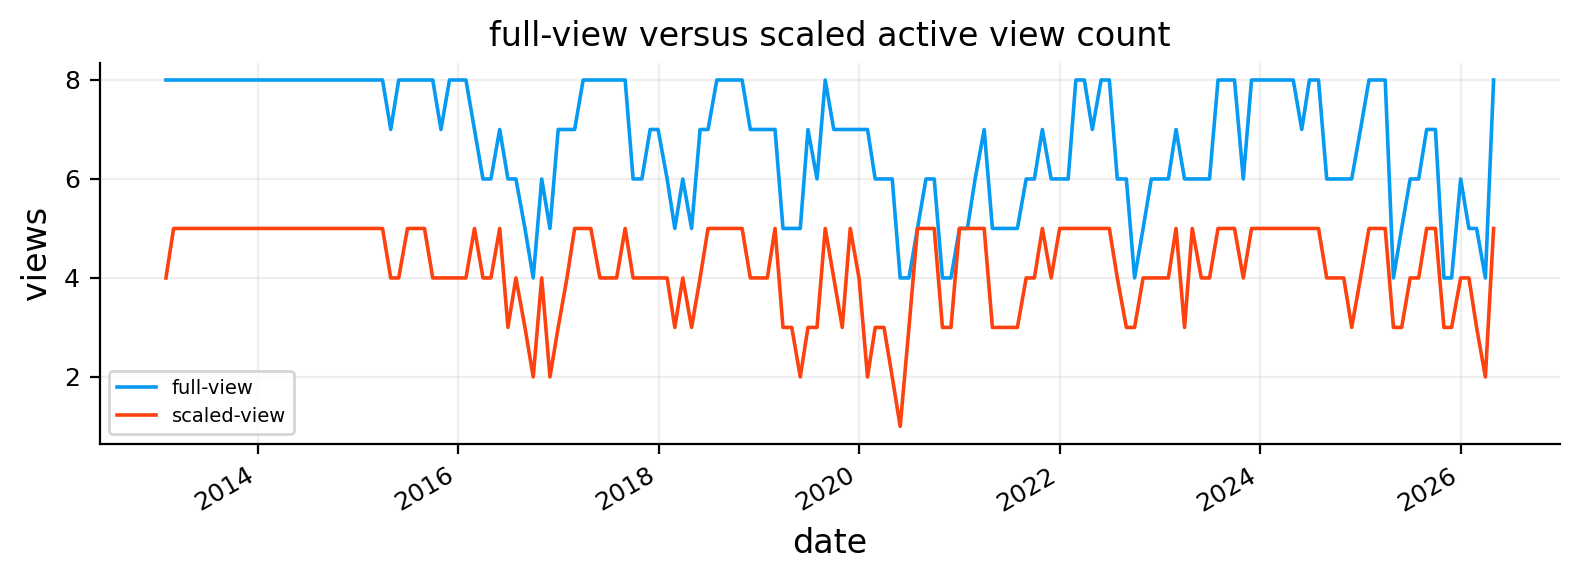

candidate_count  kept_share  avg_confidence  avg_reliability_multiplier  avg_hit_rate  avg_payoff_ir
economic_theme      view_family                                                                                                                    
real_assets         commodities_vs_bonds_pair              186      0.9140          0.5900                      0.6688        0.6345         0.3788
                    real_assets_vs_bonds                   158      0.9747          0.5649                      0.6151        0.6148         0.2169
broad_systematic    trend_breadth                          120      0.9000          0.5368                      0.5713        0.6573         0.2200
duration_defense    equity_vs_duration_pair                236      0.8983          0.5307                      0.5230        0.6051         0.1737
equity_vs_gold_pair equity_vs_gold_pair                    218      0.8991          0.5276                      0.5111        0.6467         0.2808
international       em_vs_developed_pair                   106      1.0000          0.5137                      0.4697        0.6777         1.3493
credit              credit_risk_appetite                   136      0.9706          0.4969                      0.4300        0.6315         0.3532
international       international_vs_us                    152      0.9079          0.4896                      0.4244        0.6174         0.1407
growth_equity       growth_vs_market                        66      0.8182          0.4598                      0.3884        0.5413         0.0993
real_assets         gold_vs_bonds_pair                     168      0.9762          0.4602                      0.3307        0.5408         0.1370
duration_defense    duration_defense                       210      0.8857          0.4421                      0.3141        0.5640         0.0336
                    duration_pair                           64      0.9375          0.4439                      0.3079        0.5046         0.2061
broad_systematic    cross_section_top_bottom               116      0.8276          0.4379                      0.2846        0.5788         0.2231
international       dollar_pressure_em                      64      0.9375          0.4274                      0.2695        0.5321         0.0381
small_cap           small_cap_vs_market                    158      0.8608          0.4061                      0.2416        0.4833        -0.0086
broad_systematic    risk_on_defensive_basket               112      0.8214          0.3159                      0.0844        0.5226        -0.0125
reit_rates          reit_rates_sensitivity                 142      0.3099          0.1449                      0.0178        0.4241        -0.3177
                    reit_vs_bonds_pair                     114      0.1228          0.1394                      0.0100        0.3789        -0.3897

,date,view_family,economic_theme,view_name,economic_label,long_assets,short_assets,signal_value,q_tilt,q_tilt_final,q,risk_orientation
1073,2026-04-30,commodities_vs_bonds_pair,real_assets,DBC over AGG,automatic pair-spread view,[DBC],[AGG],1.4734,0.0074,0.0074,-0.1231,neutral
1074,2026-04-30,real_assets_vs_bonds,real_assets,real assets over bonds,gold/commodity hedge versus core bonds,"[GLD, DBC]","[AGG, IEF]",1.1281,0.0067,0.0067,0.0059,neutral
1075,2026-04-30,trend_breadth,broad_systematic,risk breadth over defensive basket,market breadth and risk participation,"[DBC, EEM, IWM]","[GLD, SHY, AGG]",1.0000,0.0045,0.0045,0.0298,risk_on
1076,2026-04-30,gold_vs_bonds_pair,real_assets,GLD over AGG,automatic pair-spread view,[GLD],[AGG],0.7161,0.0046,0.0046,0.1372,neutral
1077,2026-04-30,credit_risk_appetite,credit,HYG over LQD,high-yield credit versus investment-grade credit,[HYG],[LQD],0.4253,0.0014,0.0014,0.0027,risk_on
1078,2026-04-30,equity_vs_gold_pair,equity_vs_gold_pair,GLD over SPY,automatic pair-spread view,[GLD],[SPY],-0.5330,0.0018,0.0018,0.0452,risk_off
1079,2026-04-30,equity_vs_duration_pair,duration_defense,SPY over TLT,automatic pair-spread view,[SPY],[TLT],0.5081,0.0044,0.0044,0.0796,risk_on
1080,2026-04-30,em_vs_developed_pair,international,EEM over EFA,automatic pair-spread view,[EEM],[EFA],0.4719,0.0021,0.0021,0.0525,neutral


,active_count,share_of_rebalance_dates,avg_abs_q,avg_signal_strength
view_family,,,,
equity_vs_duration_pair,116,0.7250,0.0073,1.4208
equity_vs_gold_pair,109,0.6812,0.0093,1.4519
commodities_vs_bonds_pair,93,0.5812,0.0120,1.4589
duration_defense,92,0.5750,0.0027,1.0776
gold_vs_bonds_pair,84,0.5250,0.0046,1.1951
real_assets_vs_bonds,79,0.4938,0.0066,1.0973
international_vs_us,76,0.4750,0.0039,1.0617
credit_risk_appetite,68,0.4250,0.0029,0.7633
small_cap_vs_market,67,0.4188,0.0025,1.0567


In [30]:
full_active_count = view_log.groupby("date").size().reindex(rebalance_dates[:-1], fill_value=0) if not view_log.empty else pd.Series(0, index=rebalance_dates[:-1])
scaled_active_count = scaled_view_log.groupby("date").size().reindex(rebalance_dates[:-1], fill_value=0) if not scaled_view_log.empty else pd.Series(0, index=rebalance_dates[:-1])
fig, ax = plt.subplots(figsize=(8, 3))
full_active_count.plot(ax=ax, lw=1.3, label="full-view")
scaled_active_count.plot(ax=ax, lw=1.3, label="scaled-view")
ax.set_title("full-view versus scaled active view count")
ax.set_ylabel("views")
ax.set_xlabel("date")
ax.legend()
plt.tight_layout(); plt.show()

if not scaling_log.empty:
    multiplier_summary = scaling_log.groupby(["economic_theme", "view_family"]).agg(
        candidate_count=("view_name", "size"),
        kept_share=("kept", "mean"),
        avg_confidence=("confidence", "mean"),
        avg_reliability_multiplier=("reliability_multiplier", "mean"),
        avg_hit_rate=("hit_rate", "mean"),
        avg_payoff_ir=("payoff_ir", "mean"),
    ).sort_values(["avg_reliability_multiplier", "candidate_count"], ascending=[False, False])
    display(multiplier_summary.round(4))

if not view_log.empty:
    latest_view_date = view_log["date"].max()
    latest_views_table = view_log[view_log["date"] == latest_view_date][["date", "view_family", "economic_theme", "view_name", "economic_label", "long_assets", "short_assets", "signal_value", "q_tilt", "q_tilt_final", "q", "risk_orientation"]]
    display(latest_views_table.round(4))
    view_frequency_table = view_log.groupby("view_family").agg(active_count=("view_name", "size"), share_of_rebalance_dates=("date", lambda x: x.nunique() / len(rebalance_dates[:-1])), avg_abs_q=("q_tilt_final", lambda x: np.mean(np.abs(x))), avg_signal_strength=("signal_value", lambda x: np.mean(np.abs(x)))).sort_values("active_count", ascending=False)
    display(view_frequency_table.round(4))


,asset,benchmark_weight,prior_mu,post_mu_full_learned,post_mu_full_haircut,post_mu_scaled_learned,post_mu_scaled_haircut,posterior_shift_scaled_learned,posterior_shift_scaled_haircut
0,SPY,0.2222,0.1152,0.1149,0.1152,0.1159,0.1164,0.0008,0.0012
1,QQQ,0.0808,0.1406,0.1411,0.1414,0.1422,0.1428,0.0015,0.0022
2,IWM,0.0404,0.1559,0.1562,0.1564,0.1566,0.1570,0.0007,0.0011
3,EFA,0.0909,0.1684,0.1670,0.1674,0.1681,0.1684,-0.0002,0.0001
4,IEFA,0.0000,0.1684,0.1670,0.1673,0.1681,0.1684,-0.0003,0.0000
5,EEM,0.0505,0.2187,0.2181,0.2185,0.2194,0.2199,0.0007,0.0012
6,TLT,0.0808,0.0399,0.0374,0.0379,0.0391,0.0392,-0.0008,-0.0007
7,IEF,0.0808,0.0296,0.0282,0.0285,0.0292,0.0292,-0.0004,-0.0003
8,SHY,0.0505,0.0096,0.0093,0.0093,0.0095,0.0095,-0.0001,-0.0001
9,AGG,0.1010,0.0260,0.0250,0.0252,0.0257,0.0258,-0.0003,-0.0003


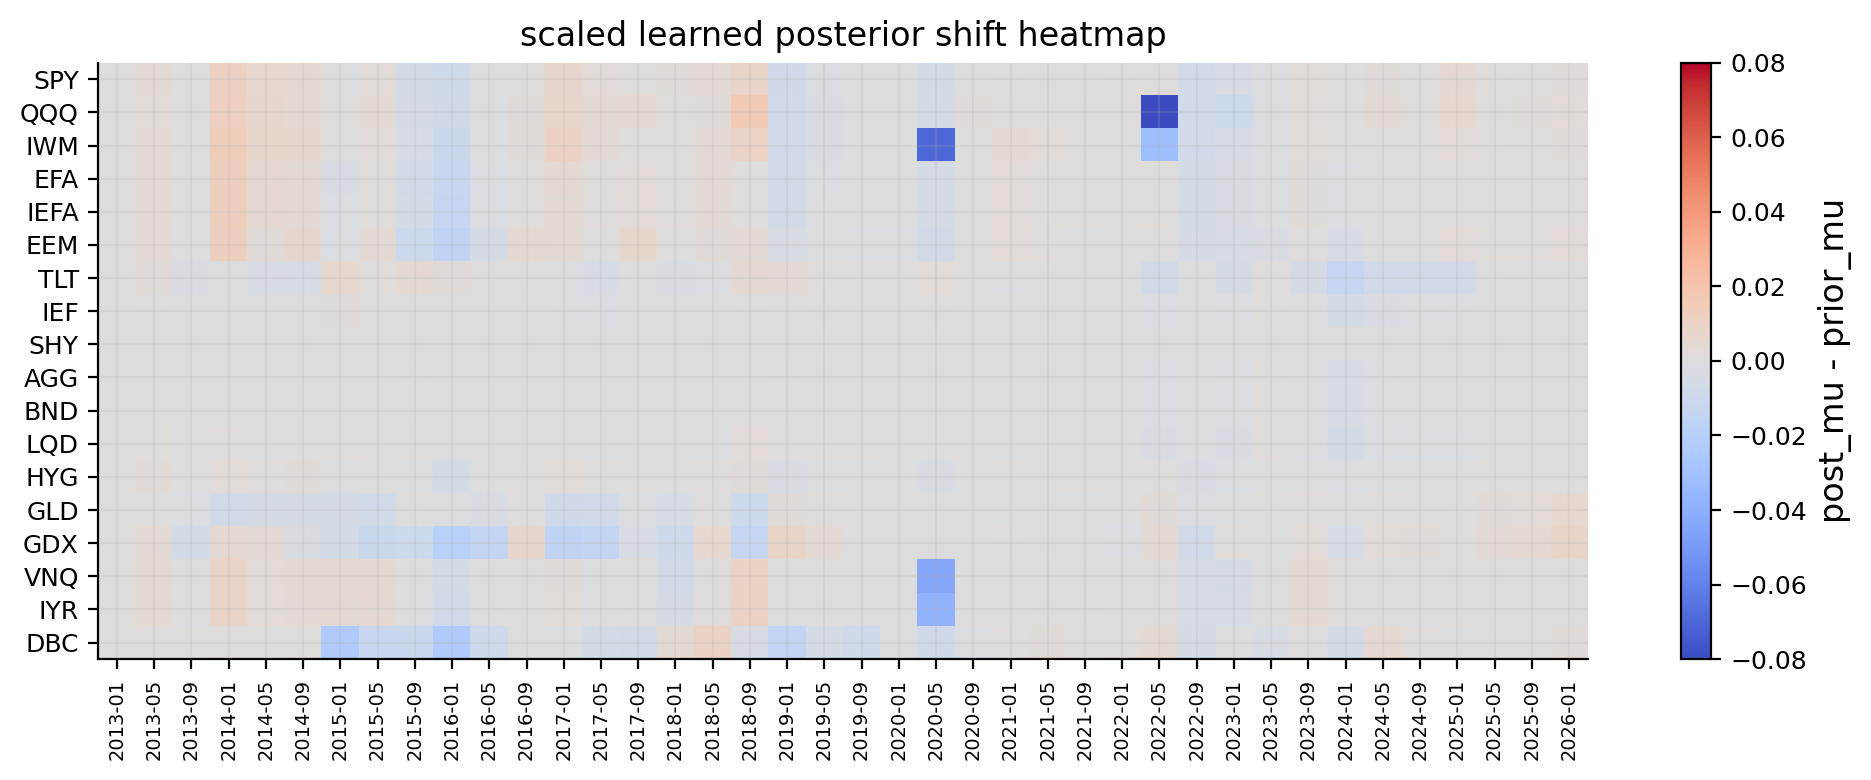

In [31]:
latest_post_date = posterior_log["date"].max() if not posterior_log.empty else pd.Timestamp(rebalance_dates[-2])
prior_latest = prior_mu_by_date[pd.Timestamp(latest_post_date)].reindex(assets)
posterior_clarity = pd.DataFrame({
    "asset": assets,
    "benchmark_weight": benchmark_w.reindex(assets).values,
    "prior_mu": prior_latest.values,
    "post_mu_full_learned": post_mu_store.get(("BL full-view learned", latest_post_date), prior_latest).reindex(assets).values,
    "post_mu_full_haircut": post_mu_store.get(("BL full-view haircut", latest_post_date), prior_latest).reindex(assets).values,
    "post_mu_scaled_learned": post_mu_store.get(("BL scaled-view learned", latest_post_date), prior_latest).reindex(assets).values,
    "post_mu_scaled_haircut": post_mu_store.get(("BL scaled-view haircut", latest_post_date), prior_latest).reindex(assets).values,
})
posterior_clarity["posterior_shift_scaled_learned"] = posterior_clarity["post_mu_scaled_learned"] - posterior_clarity["prior_mu"]
posterior_clarity["posterior_shift_scaled_haircut"] = posterior_clarity["post_mu_scaled_haircut"] - posterior_clarity["prior_mu"]
display(posterior_clarity.round(4))
learned_shift_cols = {}
for dt in sorted({key[1] for key in post_mu_store if key[0] == "BL scaled-view learned"}):
    learned_shift_cols[dt] = post_mu_store[("BL scaled-view learned", dt)].reindex(assets) - prior_mu_by_date[dt].reindex(assets)
learned_shift = pd.DataFrame(learned_shift_cols)
if not learned_shift.empty:
    selected_shift = learned_shift.iloc[:, ::max(1, learned_shift.shape[1] // 36)]
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(selected_shift, aspect="auto", cmap="coolwarm", vmin=-0.08, vmax=0.08)
    ax.set_title("scaled learned posterior shift heatmap"); ax.set_yticks(range(len(selected_shift.index)), selected_shift.index)
    ax.set_xticks(range(len(selected_shift.columns)), [d.strftime("%Y-%m") for d in selected_shift.columns], rotation=90, fontsize=7)
    fig.colorbar(im, ax=ax, label="post_mu - prior_mu"); plt.tight_layout() 
    plt.show()


In [32]:
if not view_log.empty:
    active_counts = view_log.groupby("view_family").size().rename("active_count")
    econ_label = view_log.groupby("view_family")["economic_label"].agg(lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0])
    risk_mode = view_log.groupby("view_family")["risk_orientation"].agg(lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0])
    avg_abs_q = view_log.groupby("view_family")["q_tilt_final"].agg(lambda x: np.mean(np.abs(x))).rename("avg_abs_q")
else:
    active_counts = pd.Series(dtype=float, name="active_count"); econ_label = pd.Series(dtype=object); risk_mode = pd.Series(dtype=object); avg_abs_q = pd.Series(dtype=float, name="avg_abs_q")
if not all_payoff_history.empty:
    payoff_stats = all_payoff_history.groupby("view_family").agg(hit_rate=("hit", "mean"), avg_payoff=("payoff", "mean"), payoff_vol=("payoff", "std"))
    payoff_stats["payoff_ir"] = payoff_stats["avg_payoff"] / payoff_stats["payoff_vol"].replace(0.0, np.nan)
    recent_hits = all_payoff_history.sort_values("date").groupby("view_family").tail(6).groupby("view_family")["hit"].mean().rename("recent_hit_rate")
else:
    payoff_stats = pd.DataFrame(columns=["hit_rate", "avg_payoff", "payoff_vol", "payoff_ir"]); recent_hits = pd.Series(dtype=float, name="recent_hit_rate")
conf_means = confidence_log.groupby(["view_family", "view_set", "confidence_mode"])["confidence"].mean().unstack([1, 2]) if not confidence_log.empty else pd.DataFrame()
mult_means = confidence_log[confidence_log["view_set"] == "scaled"].groupby("view_family")["reliability_multiplier"].mean().rename("avg_reliability_multiplier") if not confidence_log.empty else pd.Series(dtype=float)
reliability = pd.concat([active_counts, econ_label.rename("economic_label"), payoff_stats, avg_abs_q, recent_hits, risk_mode.rename("risk_orientation_mode"), mult_means], axis=1)
if not conf_means.empty:
    for col in conf_means.columns:
        reliability[f"avg_conf_{col[0]}_{col[1]}"] = conf_means[col]
for col in ["avg_conf_full_learned", "avg_conf_full_haircut", "avg_conf_scaled_learned", "avg_conf_scaled_haircut", "avg_reliability_multiplier"]:
    if col not in reliability.columns:
        reliability[col] = np.nan

def reliability_label(row):
    count = row.get("active_count", 0); hit_rate = row.get("hit_rate", np.nan); payoff_ir = row.get("payoff_ir", np.nan); risk = row.get("risk_orientation_mode", "neutral")
    if count < 10:
        return "low evidence"
    if np.isfinite(payoff_ir) and np.isfinite(hit_rate) and payoff_ir > 0 and hit_rate > 0.55:
        return "reliable positive"
    if (np.isfinite(hit_rate) and hit_rate < 0.45) or (np.isfinite(payoff_ir) and payoff_ir < 0):
        return "unstable"
    if risk == "risk_off":
        return "mostly defensive"
    if risk == "risk_on":
        return "mostly risk-on"
    return "mixed but useful"

def final_reliability_decision(row):
    count = row.get("active_count", 0)
    hit_rate = row.get("hit_rate", np.nan)
    payoff_ir = row.get("payoff_ir", np.nan)
    recent_hit_rate = row.get("recent_hit_rate", np.nan)
    multiplier = row.get("avg_reliability_multiplier", np.nan)
    if np.isfinite(hit_rate) and np.isfinite(payoff_ir) and hit_rate < 0.42 and payoff_ir < -0.10:
        return "drop only when active"
    if np.isfinite(recent_hit_rate) and recent_hit_rate < 0.30:
        return "drop only when recent weak"
    if count < 10:
        return "scale down, low evidence"
    if np.isfinite(hit_rate) and np.isfinite(payoff_ir) and hit_rate > 0.55 and payoff_ir > 0:
        return "keep with scaling"
    if np.isfinite(multiplier) and multiplier < 0.25:
        return "mostly small tilt"
    return "diagnostic and scaled"

reliability["interpretation"] = reliability.apply(reliability_label, axis=1)
reliability["final_decision"] = reliability.apply(final_reliability_decision, axis=1)
reliability = reliability[["economic_label", "active_count", "hit_rate", "avg_payoff", "payoff_vol", "payoff_ir", "avg_abs_q", "avg_conf_full_learned", "avg_conf_full_haircut", "avg_conf_scaled_learned", "avg_conf_scaled_haircut", "avg_reliability_multiplier", "recent_hit_rate", "risk_orientation_mode", "interpretation", "final_decision"]].sort_values("active_count", ascending=False)
display(reliability.round(4))


,economic_label,active_count,hit_rate,avg_payoff,payoff_vol,payoff_ir,avg_abs_q,avg_conf_full_learned,avg_conf_full_haircut,avg_conf_scaled_learned,avg_conf_scaled_haircut,avg_reliability_multiplier,recent_hit_rate,risk_orientation_mode,interpretation,final_decision
view_family,,,,,,,,,,,,,,,,
equity_vs_duration_pair,automatic pair-spread view,116,0.5983,0.0090,0.0519,0.1732,0.0073,0.5549,0.5146,0.5677,0.5408,0.5971,0.6667,risk_on,reliable positive,keep with scaling
equity_vs_gold_pair,automatic pair-spread view,109,0.5463,0.0014,0.0596,0.0234,0.0093,0.5512,0.5040,0.5561,0.5171,0.5536,0.5000,risk_on,mostly risk-on,diagnostic and scaled
commodities_vs_bonds_pair,automatic pair-spread view,93,0.5326,0.0091,0.0559,0.1634,0.0120,0.6158,0.5641,0.6413,0.5940,0.7588,0.3333,neutral,mixed but useful,diagnostic and scaled
duration_defense,duration defense versus equity/credit risk,92,0.6000,0.0035,0.0369,0.0941,0.0027,0.4732,0.4612,0.4358,0.4149,0.2558,1.0000,risk_on,reliable positive,keep with scaling
gold_vs_bonds_pair,automatic pair-spread view,84,0.5663,0.0067,0.0445,0.1495,0.0046,0.4690,0.4513,0.4708,0.4621,0.3442,0.6667,neutral,reliable positive,keep with scaling
real_assets_vs_bonds,gold/commodity hedge versus core bonds,79,0.5897,0.0078,0.0367,0.2137,0.0066,0.5756,0.5543,0.5608,0.5373,0.5799,0.8333,neutral,reliable positive,keep with scaling
international_vs_us,international equity versus US equity,76,0.5263,0.0004,0.0312,0.0114,0.0039,0.5091,0.4702,0.5433,0.5048,0.5165,0.0000,risk_on,mostly risk-on,drop only when recent weak
credit_risk_appetite,high-yield credit versus investment-grade credit,68,0.5522,0.0023,0.0176,0.1330,0.0029,0.5257,0.4682,0.5343,0.4776,0.4805,0.3333,risk_on,reliable positive,keep with scaling
small_cap_vs_market,small-cap risk appetite versus broad US equity,67,0.5696,0.0018,0.0319,0.0572,0.0025,0.4412,0.4353,0.4430,0.4366,0.2888,0.6667,neutral,reliable positive,keep with scaling


In [33]:
decision_table = reliability[["active_count", "hit_rate", "payoff_ir", "recent_hit_rate", "avg_reliability_multiplier", "risk_orientation_mode", "interpretation", "final_decision"]].copy()
display(decision_table.round(4))
scale_reason_table = scaling_log.groupby("scale_reason").size().rename("count").sort_values(ascending=False).to_frame()
scale_reason_table["share"] = scale_reason_table["count"] / scale_reason_table["count"].sum()
display(scale_reason_table.round(4))


,active_count,hit_rate,payoff_ir,recent_hit_rate,avg_reliability_multiplier,risk_orientation_mode,interpretation,final_decision
view_family,,,,,,,,
equity_vs_duration_pair,116,0.5983,0.1732,0.6667,0.5971,risk_on,reliable positive,keep with scaling
equity_vs_gold_pair,109,0.5463,0.0234,0.5000,0.5536,risk_on,mostly risk-on,diagnostic and scaled
commodities_vs_bonds_pair,93,0.5326,0.1634,0.3333,0.7588,neutral,mixed but useful,diagnostic and scaled
duration_defense,92,0.6000,0.0941,1.0000,0.2558,risk_on,reliable positive,keep with scaling
gold_vs_bonds_pair,84,0.5663,0.1495,0.6667,0.3442,neutral,reliable positive,keep with scaling
real_assets_vs_bonds,79,0.5897,0.2137,0.8333,0.5799,neutral,reliable positive,keep with scaling
international_vs_us,76,0.5263,0.0114,0.0000,0.5165,risk_on,mostly risk-on,drop only when recent weak
credit_risk_appetite,68,0.5522,0.1330,0.3333,0.4805,risk_on,reliable positive,keep with scaling
small_cap_vs_market,67,0.5696,0.0572,0.6667,0.2888,neutral,reliable positive,keep with scaling


,count,share
scale_reason,,
kept,2122,0.8401
recent hit too low,226,0.0895
clearly bad,178,0.0705


,asset,active_weight_scaled_risk_controlled
0,AGG,-0.0788
1,SHY,-0.0394
2,HYG,-0.0283
3,IEF,-0.0176
4,DBC,-0.0046
5,GDX,0.0000
6,BND,0.0000
7,VNQ,0.0003
8,LQD,0.0022
9,EEM,0.0022


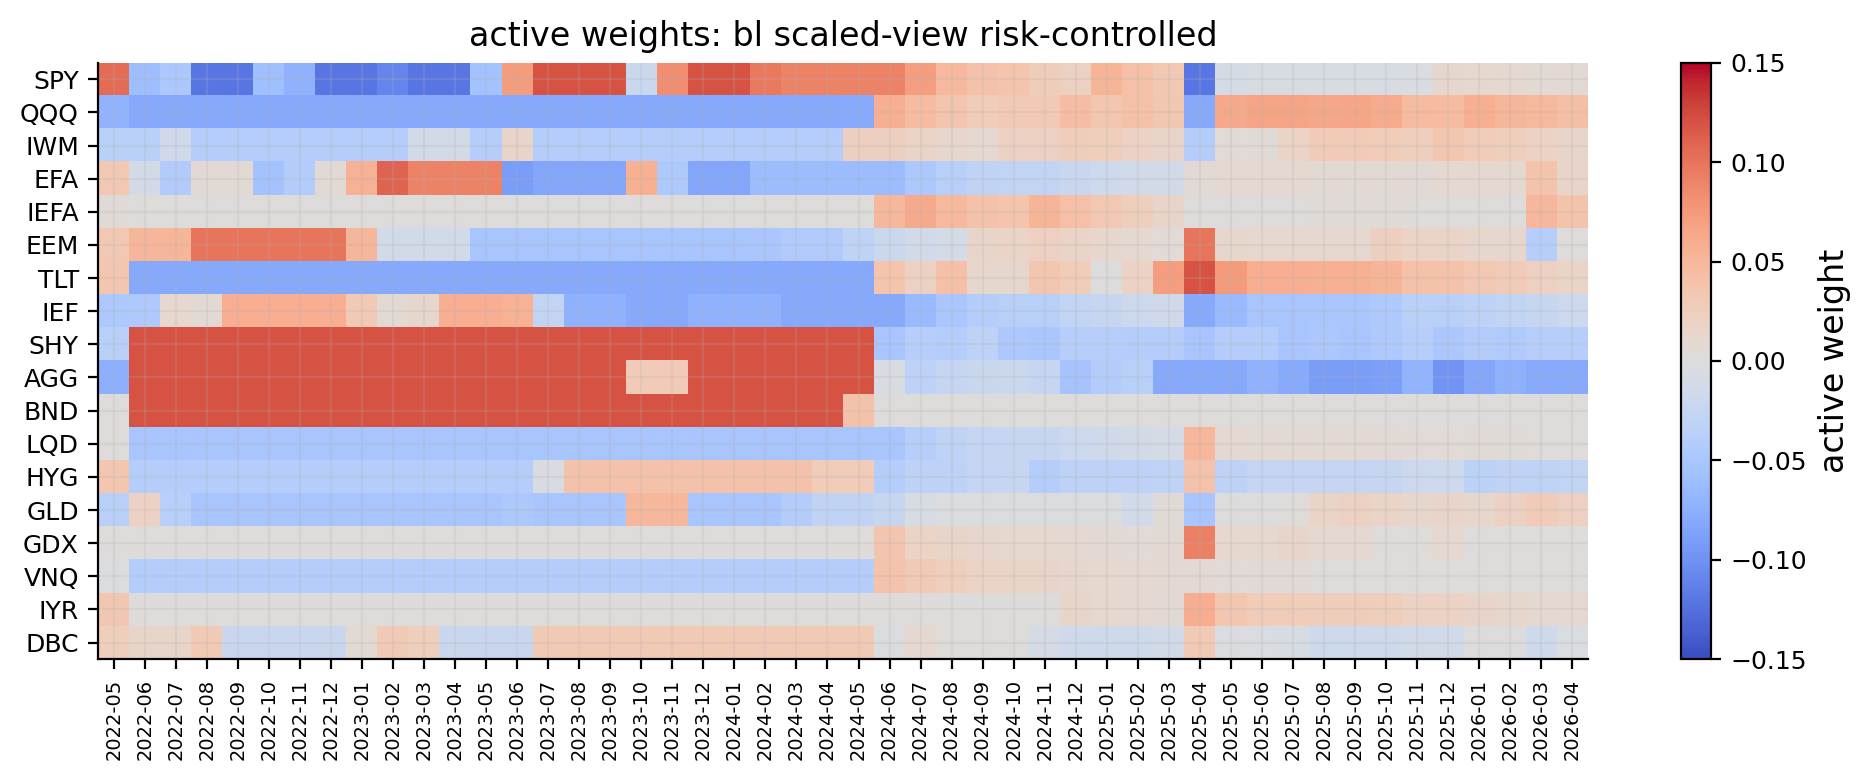

In [34]:
risk_controlled_weights = weights_by_strategy["BL scaled-view risk-controlled"].reindex(columns=assets)
benchmark_aligned = benchmark_w.reindex(assets).fillna(0.0)
active_w_scaled_risk = risk_controlled_weights.subtract(benchmark_aligned, axis=1)
latest_active_w = active_w_scaled_risk.iloc[-1].sort_values()
display(pd.DataFrame({"asset": latest_active_w.index, "active_weight_scaled_risk_controlled": latest_active_w.values}).round(4))

frame = active_w_scaled_risk.iloc[-48:].T
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(frame, aspect="auto", cmap="coolwarm", vmin=-0.15, vmax=0.15)
ax.set_title("active weights: bl scaled-view risk-controlled")
ax.set_yticks(range(len(frame.index)), frame.index)
ax.set_xticks(range(len(frame.columns)), [d.strftime("%Y-%m") for d in frame.columns], rotation=90, fontsize=7)
fig.colorbar(im, ax=ax, label="active weight")
plt.tight_layout(); plt.show()


In [35]:
def active_risk_series(weights):
    rows = []
    for dt, row in weights.iterrows():
        dt = pd.Timestamp(dt)
        if dt not in cov_by_date:
            continue
        diff = row.reindex(assets).fillna(0.0).values - benchmark_aligned.values
        cov_ann = cov_by_date[dt].loc[assets, assets].values
        rows.append((dt, float(np.sqrt(max(diff @ cov_ann @ diff, 0.0)))))
    return pd.Series(dict(rows)).sort_index()

active_diagnostics = pd.DataFrame({
    "avg_active_risk": {
        "BL full-view learned": active_risk_series(weights_by_strategy["BL full-view learned"].reindex(columns=assets)).mean(),
        "BL scaled-view learned": active_risk_series(weights_by_strategy["BL scaled-view learned"].reindex(columns=assets)).mean(),
        "BL scaled-view haircut": active_risk_series(weights_by_strategy["BL scaled-view haircut"].reindex(columns=assets)).mean(),
        "BL scaled-view risk-controlled": active_risk_series(weights_by_strategy["BL scaled-view risk-controlled"].reindex(columns=assets)).mean(),
    },
    "avg_turnover": {
        "BL full-view learned": turnover_by_strategy["BL full-view learned"].mean(),
        "BL scaled-view learned": turnover_by_strategy["BL scaled-view learned"].mean(),
        "BL scaled-view haircut": turnover_by_strategy["BL scaled-view haircut"].mean(),
        "BL scaled-view risk-controlled": turnover_by_strategy["BL scaled-view risk-controlled"].mean(),
    },
})
display(active_diagnostics.round(4))


,avg_active_risk,avg_turnover
BL full-view learned,0.0302,0.1163
BL scaled-view learned,0.0256,0.0796
BL scaled-view haircut,0.0251,0.0810
BL scaled-view risk-controlled,0.0232,0.0852
